# **데이터 수집**

> **Google Colab 원본 반영판**  
> 이 Notebook은 논문용 Jupyter 원본의 **데이터 수집 → 전체 탐색 → 데이터 처리 → 세부 탐색 → 그래프 분석 → 개별 천체 2D/3D 궤도 분석 → 분류 정답 확인** 흐름과 대부분의 코드 셀을 유지합니다.  
> Colab과 충돌하는 Jupyter nbextensions 및 Dash 서버 UI만 **Colab 입력폼 + Plotly** 방식으로 바꾸었습니다.

관련 연구: **조훈 · 손정주, 「태양계 천체의 역학적 분류를 위한 데이터 사이언스 기반 천문 교육 콘텐츠 개발」**


## 패키지 라이브러리 불러오기

In [ ]:
# 처음 실행할 때 Colab에 필요한 패키지를 설치합니다.
%pip -q install "plotly==5.15.0" astropy scikit-learn
print("✅ Colab 패키지 설치 완료")


In [ ]:
# 공식 GitHub 저장소에서 원본 분석 함수와 전체 카탈로그를 자동으로 준비합니다.
from pathlib import Path
from urllib.request import urlretrieve, urlopen
import base64, zlib, os

BASE = "https://raw.githubusercontent.com/GodTANKS/Solar-System-Dynamical-Classification-Education/main"
WORK = Path("/content/solar_system_dynamics")
WORK.mkdir(parents=True, exist_ok=True)

# 논문용 원본 분석 함수 파일
urlretrieve(f"{BASE}/src/solarsystem_analysis13.py", WORK / "solarsystem_analysis13.py")

# 전체 CSV를 압축된 텍스트 조각 12개에서 복원
encoded = []
for i in range(1, 13):
    url = f"{BASE}/data/catalog_b64/part-{i:02d}.txt"
    encoded.append(urlopen(url).read().decode("ascii").strip())
raw_csv = zlib.decompress(base64.b64decode("".join(encoded)))
(WORK / "dwarfplanet_asteroid_comet_analysis.csv").write_bytes(raw_csv)

os.chdir(WORK)
print("✅ 원본 분석 함수 준비 완료")
print("✅ 전체 소천체 카탈로그 복원 완료:", len(raw_csv), "bytes")


### Colab 환경 안내
원본 Jupyter Notebook에 있던 `jupyter_nbextensions_configurator`와 목차 확장 기능은 Colab에서는 필요하지 않으므로 생략합니다.  
그 외 분석 흐름과 원본 함수는 그대로 이어서 사용합니다.


In [ ]:
from solarsystem_analysis13 import *  # 논문용 원본 분석 함수
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder
from astropy.time import Time
import numpy as np
import pandas as pd
from plotly.subplots import make_subplots
import plotly.graph_objs as go
import plotly
import plotly.express as px
from IPython.display import display, HTML

print("✅ 원본 분석 함수 및 라이브러리 불러오기 완료")


## 주피 노트북 셀 너비 조절

In [ ]:
# Colab에서는 셀 폭을 별도로 조절하지 않아도 됩니다.
print("✅ Colab 화면 폭을 기본값으로 사용합니다.")


## 추가 함수 실행하기

In [ ]:
# 행성과 소천체의 탐색 시간과 위치 정보가 담긴 세트와 위치 정보만 담긴 데이터 세트 출력 함수
def individual_to_dat_df(object_pdes_list, start_time, finish_time, time_hour):
  # 함수 입력값(천체 식별번호(pdes) 리스트, 탐색 시작 시간(고레고리력), 탐색 종료 시간(그레고리력), 시간 간격(그레고리력, 시간 단위))
  s_jd = Time(start_time, format='iso', scale='utc').jd # 율리우스력 일로 변환
  f_jd = Time(finish_time, format='iso', scale='utc').jd # 율리우스력 일로 변환
  t_d = time_hour/24 # 시간 단위를 일 단위로 변환
  for pdes in object_pdes_list:
    df_o = df[ df['pdes'] == pdes ] # df 데이터 세트에서 입력된 소천체의 기본명칭을 갖는 데이터 추출
    df_o_1 = df_o[df_o.pr_class != 'Satellite'] # 위 데이터 세트에서 주요 유형이 Satellite(위성)가 아닌 데이터만 다시 추출
    dat_df_o = object_datetimeframe(df_o_1, s_jd, f_jd, t_d) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 소천체의 시간 데이터 세트 산출
    dat_df_p = planet_datetimeframe(s_jd, f_jd, t_d) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 행성의 시간 데이터 세트 산출
    if pdes == object_pdes_list[0]:
      dat_df_p_o = dataframe_concatenate(dat_df_p, dat_df_o) # 행성의 시간 데이터 세트와 소천체의 시간 데이터 세트 합치기
      df_p_o = dataframe_concatenate(df_p, df_o) # 행성의 데이터 세트와 소천체의 데이터 세트 합치기
    else:
      dat_df_p_o = dataframe_concatenate(dat_df_p_o, dat_df_o)
      df_p_o = dataframe_concatenate(df_p_o, df_o)
  df_p_o_all = df_p_o # 시간 데이터 세트 없이 행성과 분석하고자 하는 천체의 정보가 합쳐진 데이터 프레임
  df_p_o_all_1 = df_p_o_all[df_p_o_all.pr_class != 'Satellite'] # 시간 데이터 세트가 없으며, 위성 정보도 없는 행성과 분석하고자 하는 천체의 정보가 합쳐진 데이터 세트
  dat_df_p_o_lb_1 = pr_dt_class_labelencoder(dat_df_p_o) # 위성 정보가 없으며, 합쳐진 시간 데이터 세트의 주요유형과 세부유형의 문자형 데이터를 숫자형으로 레이블 변환
  dat_df_p_o_lb_2 = dat_df_p_o_lb_1.drop(columns='pr_class')
  dat_df_p_o_lb_3 = dat_df_p_o_lb_2.drop(columns='dt_class')
  dat_df_p_o_lb_4 = dat_df_p_o_lb_3.drop(columns='neo')
  dat_df_p_o_lb_5 = dat_df_p_o_lb_4.drop(columns='pha')
  dat_df_p_o_lb_6 = dat_df_p_o_lb_5.drop(columns='pr_label')
  dat_df_p_o_lb_7 = dat_df_p_o_lb_6.drop(columns='dt_label')
  condition = dat_df_p_o_lb_1 ['pr_class'] == 'Planet'
  dat_df_p_o_lb_7.loc[condition, 'code'] = 2
  dat_df_p_o_lb_7.loc[~condition, 'code'] = 1
  return dat_df_p_o_lb_7, df_p_o_all_1, df_p_o_all # 함수 출력값

In [ ]:
# 3d 천체 시뮬레이션 출력 함수
def threed_simulation(dat_df_p_o_lb_7, df_p_o_all_1, text_tf, nps):
  # 함수 입력값(시간과 위 좌표 및 레이블이 지정된 데이터 세트, 위치 좌표가 있는 데이터 세트,
  # 텍스트 표시 여부(None, full_name), 궤도선 표시 유무(True, False), 궤도를 그리는데 필요한 점 개수)
  # 애니메이션 구동 파라미터
  colors = px.colors.qualitative.Dark24 # 색깔 지정
  fig = px.scatter_3d(data_frame = dat_df_p_o_lb_7, # 데이터 프레임에 '행성와 개별 소천체의 시간 데이터 세트' 열 대입
                      x="x", y="y", z='z', # x, y, z 입력값에 'x, y, z축' 열 대입
                      animation_frame="cal(TDB)", # 애니메이션 구동 기준에 '입력 시간 그레고리력' 열 대입
                      size='code', # 마커 사이즈
                      size_max=10, # 마커 사이즈 최대 크기 지정
                      hover_name='full_name', # 마우스를 올렸을때 나타나는 이름에 '천체 명칭' 열 대입
                      hover_data=['pdes', 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid'], # 마우스를 올렸을때 나타나는 데이터 정보에 열 대입
                      text=text_tf # 그림 위에 항상 표시되는 텍스트 (None: 안보임, 'full_name': 천체명 보임)
                      )
  # 태양 파라미터
  fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], # 태양의 x, y, z 좌표 데이터 입력
                             mode='markers', # 3d 산점도 데이터의 표시 모드 종류 입력
                             marker=dict(color='orange', size=4), # 마커 색, 크기, 기호 입력
                             name='Sun' # 표시되는 명칭 입력
                             )
                )
  # 천체 궤도 파라미터
  for s in range(len(df_p_o_all_1)):
    n = df_p_o_all_1.loc[s, 'full_name'] # 천체의 명칭
    a = df_p_o_all_1.loc[s, 'a'] # 천체의 장반경(태양과의 거리)(au)
    e = df_p_o_all_1.loc[s, 'e'] # 천체의 이심률
    i = df_p_o_all_1.loc[s, 'i'] # 천체의 경사각(황도면을 기준으로 기울어진 각도)(degree)
    om = df_p_o_all_1.loc[s, 'om'] # 천체의 승교점 경도(황위가 -에서 +로 올라가면서 황도면과 교차하는 지점의 황경)(degree)
    w = df_p_o_all_1.loc[s, 'w'] # 천체의 근일점 이각(승교점에서 근일점까지의 반시계방향(황경이 증가하는 방향의 이각)(degree)
    r ,x ,y, z = orbit_line(a, e, i, om, w, nps) # 천체 궤도 선 산출 함수로 태양과의 거리, xyz 좌표 산출
    if s < 8:
      fig.add_trace(go.Scatter3d(x=x, y=y,z=z, # 3d 산점도 xyz그래프
                                 mode='lines', # 선 그리기 모드 지정
                                 line=dict(color=colors[0], width=5),
                                           ### <선의 색(color) & 폭(widht) 지정, 폭은 자연수 입력
                                           ### 모든 천체를 각기 다른 색깔로 표현하기를 원하면: color=colors[s]로 입력
                                           ### 세부유형별로 매칭된 색깔로 표현하기를 원하면: color=prdt_color[dt]로 입력>
                                 name=n # 표시되는 명칭 입력(명칭 변수)
                                )
                    )
    else:
      fig.add_trace(go.Scatter3d(x=x, y=y,z=z, # 3d 산점도 xyz그래프
                             mode='lines', # 선 그리기 모드 지정
                             line=dict(color=colors[s-7], width=3),
                                       ### <선의 색(color) & 폭(widht) 지정, 폭은 자연수 입력
                                       ### 모든 천체를 각기 다른 색깔로 표현하기를 원하면: color=colors[s]로 입력
                                       ### 세부유형별로 매칭된 색깔로 표현하기를 원하면: color=prdt_color[dt]로 입력>
                             name=n # 표시되는 명칭 입력(명칭 변수)
                            )
                )
  return fig

In [ ]:
# 2d 천체 시뮬레이션 X-Y축 출력 함수
def twod_simulation_xy(dat_df_p_o_lb_7, df_p_o_all_1, text_tf, nps):
  # 함수 입력값(시간과 위 좌표 및 레이블이 지정된 데이터 세트, 위치 좌표가 있는 데이터 세트
  # 텍스트 표시 여부(None, full_name), 궤도를 그리는데 필요한 점 개수)
  # 애니메이션 구동 파라미터
  fig = px.scatter(data_frame = dat_df_p_o_lb_7, # 데이터 프레임에 '행성와 개별 소천체의 시간 데이터 세트' 열 대입
                   x="x", y="y", # x, y, z 입력값에 'x, y, z축' 열 대입
                   animation_frame="cal(TDB)", # 애니메이션 구동 기준에 '입력 시간 그레고리력' 열 대입
                   size='code', # 마커 사이즈에 '주요유형 레이블' 열 대입
                   size_max=10, # 마커 사이즈 최대 크기 지정
                   hover_name='full_name', # 마우스를 올렸을때 나타나는 이름에 '천체 명칭' 열 대입
                   hover_data=['pdes', 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid'], # 마우스를 올렸을때 나타나는 데이터 정보에 열 대입
                   text=text_tf # 그림 위에 항상 표시되는 텍스트
                   )
  # 태양 파라미터
  fig.add_trace(go.Scatter(x=[0], y=[0],
                            mode='markers',
                            marker=dict(color='orange', size=7),
                            name='Sun'
                            )
                )
  df_line_all = df_orbit_line_xyz(df_p_o_all_1, nps)
  x_max = np.max(np.abs(df_line_all['x']))
  y_max = np.max(np.abs(df_line_all['y']))
  xy_max = np.max(np.abs([x_max, y_max]))
  fig1 = px.line(df_line_all, x='x', y='y', color='full_name',
                 hover_data=['pdes', 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid'], hover_name='full_name')
  fig.add_traces(fig1.data)
  fig.update_xaxes(title_text="x", range=(-(xy_max+5), xy_max+5))
  fig.update_yaxes(title_text="y", range=(-(xy_max+5), xy_max+5))
  return fig

In [ ]:
# 2d 천체 시뮬레이션 nps-z축 출력 함수
def twod_simulation_npsz(df_p_o_all_1, nps):
  # 함수 입력값(위치 좌표가 있는 데이터프레임, 궤도를 그리는데 필요한 점 개수)
  df_line_all = df_orbit_line_xyz(df_p_o_all_1, nps)
  fig = px.line(df_line_all, x='nps', y='z', color='full_name',
                hover_data=['pdes', 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid',], hover_name='full_name')
  return fig

In [ ]:
# 데이터 프레임(세트)들을 행 방향으로 합쳐주는 함수(10개까지 가능)
def dataframe_concatenate(dataframe1, dataframe2=None, dataframe3=None, dataframe4=None, dataframe5=None,
                          dataframe6=None, dataframe7=None, dataframe8=None, dataframe9=None, dataframe10=None):
  # 함수 입력값(데이터 프레임 1번째, 데이터 프레임 2번째, 데이터 프레임 3번째, 데이터 프레임 4번째, 데이터 프레임 5번째)
  dfc = pd.concat([dataframe1, dataframe2, dataframe3, dataframe4, dataframe5,
                   dataframe6, dataframe7, dataframe8, dataframe9, dataframe10], axis=0) # 행 방향으로 데이터 프레임 합치기
  dfc.reset_index(drop=True, inplace=True) # 각 데이터 프레임의 기존 인덱스는 모두 초기화
  return dfc # 함수값 출력

In [ ]:
# 입력한 데이터 세트 변수와 사전에 천체를 분류한 데이터 세트 변수를 서로 매칭시켜주는 함수
def dataframe_input(input_dataframe):
  # 함수 입력값(입력되는 데이터 세트)
  if input_dataframe == 'df':
    dataframe = df
  elif input_dataframe == 'df_1':
    dataframe = df_1  
  elif input_dataframe == 'df_p':
    dataframe = df_p
  elif input_dataframe == 'df_p_1':
    dataframe = df_p_1
  elif input_dataframe == 'df_p_2':
    dataframe = df_p_2
  elif input_dataframe == 'df_d':
    dataframe = df_d
  elif input_dataframe == 'df_a':
    dataframe = df_a
  elif input_dataframe == 'df_a_0':
    dataframe = df_a_0
  elif input_dataframe == 'df_a_1':
    dataframe = df_a_1
  elif input_dataframe == 'df_a_2':
    dataframe = df_a_2
  elif input_dataframe == 'df_a_3':
    dataframe = df_a_3
  elif input_dataframe == 'df_a_4':
    dataframe = df_a_4
  elif input_dataframe == 'df_c':
    dataframe = df_c
  elif input_dataframe == 'df_c_1':
    dataframe = df_c_1
  elif input_dataframe == 'df_c_2':
    dataframe = df_c_2
  elif input_dataframe == 'df_c_3':
    dataframe = df_c_3
  elif input_dataframe == 'df_c_4':
    dataframe = df_c_4
  elif input_dataframe == 'df_c_5':
    dataframe = df_c_5
  return dataframe

In [ ]:
# 장반경: 0~40 au, 이심률: 0~1, 경사각: 0의 목성 티세랑(juvian tisserand, Tj) 산출 함수
def jupiter_tisserand():
  ja = df_p.loc[4, 'a'] # 목성의 장반경
  tj2 = 2 # 목성 티세랑 2
  tj3 = 3 # 목성 티세랑 3
  aa = np.linspace(0, 40, 401) # 인위적으로 0~40 au 생성(400등분)
  ej2_2 = 1-(1/4)*((tj2 - ja/aa )**2)*(ja/aa)*np.cos(0) # 목성 티세랑이 2일때 제곱 이심률
  ej3_2 = 1-(1/4)*((tj3 - ja/aa )**2)*(ja/aa)*np.cos(0) # 목성 티세랑이 3일때 제곱 이심률
  ej2 = np.sqrt(ej2_2) # 목성 티세랑이 2일때 제곱된 이심률을 제곱근 처리
  ej3 = np.sqrt(ej3_2) # 목성 티세랑이 3일때 제곱된 이심률을 제곱근 처리
  df_tj2 = pd.DataFrame({'name':'Tj2', # 목성 티세랑이 2일때 0~40au에서 이심률 데이터 세트
                         'a':aa[26:], # a에 400등분된 0~40 au 대입
                         'e':ej2[26:]}) # e에 목성 티세랑이 2일때 제곱 이심률 대입
  df_tj3 = pd.DataFrame({'name':'Tj3', # 목성 티세랑이 3일때 0~40au에서 이심률 데이터 세트
                         'a':aa[17:], # a에 400등분된 0~40 au 대입
                         'e':ej3[17:]}) # e에 목성 티세랑이 3일때 제곱 이심률 대입
  df_tj2_3 = pd.concat([df_tj2, df_tj3], axis=0) # 목성 티세랑 2와 3의 데이터 세트
  return df_tj2_3  # 함수값 출력

In [ ]:
# 현재 행성 궤도 데이터 요소 정보
now_date = Time.now() # 그레고리력 현재 UTC 시간(UTC = 한국 현재 시간(KST) - 9시)
print('분석 시작 현재 UTC 시간(UTC = 한국 시간 - 9시간):', now_date)
j_d = now_date.jd
# 현재 그레고리력 날짜를 율리우스력 날짜로 변환
df_p = planet_orbit_element(j_d) # 현재 행성 궤도 요소
# print('현재 행성 궤도 요소 정보') # 행성 궤도 요소 정보 출력
display(df_p) # 데이터 세트 출력

## 데이터 불러오기

In [ ]:
df_n = pd.read_csv("dwarfplanet_asteroid_comet_analysis.csv")  # 태양계 천체 csv파일 불러오기

# **데이터 탐색**

## 데이터 전체 탐색

### 데이터 전체 정보 확인하기

In [ ]:
df = dataframe_concatenate(df_p, df_n) # 현재 행성 데이터 정보와 불러온 천체 데이터 합치기(행 방향)
print('전체 행렬 구조:', df.shape) # 행렬 구조 츨력
print('열 개수:', df.columns.size) # 열 개수 출력
print('행 개수:', df.index.size) # 인덱스 개수 출력
display(df) # 데이터 세트 출력

### 데이터 요약 정보 확인하기

In [ ]:
print(df.info()) # 요약 정보 출력
# 데이터 타입 중 object:문자형, folat64:소수형을 의미
# 하나의 열(속성)을 구성하는 대부분이 folat라도 하나라도 object면 object로 표현됨

### 범주형 속성의 데이터 개수 확인하기

In [ ]:
print(df['pr_class'].value_counts()) # 범주형 속성인 '주요유형' 열의 데이터 종류와 개수 출력
print(df['dt_class'].value_counts()) # 범주형 속성인 '세부유형' 열의 데이터 종류와 개수 출력
print(df['neo'].value_counts()) # 범주형 속성인 '근지구형' 열의 데이터 종류와 개수 출력
print(df['pha'].value_counts()) # 범주형 속성인 '지구위협형' 열의 데이터 종류와 개수 출력

### 데이터 기술 통계 확인하기

In [ ]:
display(df.describe()) # 기술 통계 출력

# **데이터 처리**

## **데이터 변환**

### '주요유형' 열의 데이터를 천체 유형별로 분류 추출하기

In [ ]:
df_p = df[ df['pr_class'] == 'Planet' ] # '주요유형'열 중 행성에 속한 모든 데이터 추출
df_d = df[ df['pr_class'] == 'Dwarfplanet'] # '주요유형'열 중 왜소행성에 속한 모든 데이터 추출
df_a = df[ df['pr_class'] == 'Asteroid' ] # '주요유형'열 중 소행성에 속한 모든 데이터 추출
df_c = df[ df['pr_class'] == 'Comet' ] # '주요유형'열 중 혜성에 속한 모든 데이터 추출

display('행성 개수', df_p.index.size, df_p) # 행성 데이터 세트 출력
display('왜소행성 개수', df_d.index.size, df_d) # 왜소행성 데이터 세트 출력
display('소행성 개수', df_a.index.size, df_a) # 소행성 데이터 세트 출력
display('혜성 개수', df_c.index.size, df_c) # 혜성 데이터 세트 출력

### '세부유형' 열의 데이터를 천체 유형별로 분류 추출하기

In [ ]:
df_p_1 = df_p[ df_p['dt_class'] == 'TP' ] # '세부유형'열 중 '지구형'에 속한 모든 데이터 추출
df_p_2 = df_p[ df_p['dt_class'] == 'JP' ] # '세부유형'열 중 '목성형'에 속한 모든 데이터 추출

display('행성 지구형 개수', df_p_1.index.size, df_p_1) # 행성 지구형 데이터 세트 출력
display('행성 목성형 개수', df_p_2.index.size, df_p_2) # 행성 목성형 데이터 세트 출력

In [ ]:
df_a_0 = df_a[ df_a['pha'] == 'Y' ] # 소행성의 'pha'열 중 지구위협형에 속한 모든 데이터 추출 / 근지구형의 소행성 중 일부가 이에 해당
df_a_1 = df_a[ df_a['neo'] == 'Y' ] # 소행성의 'neo'열 중 근지구형에 속한 모든 데이터 추출 / AOP: 아폴로군, AMO: 아모르군, ATE: 아텐군, IEO: 아티라군 모두가 이에 해당
df_a_2 = df_a[ df_a['dt_class'] == 'MBA' ] # 소행성의 '세부유형'열 중 주 소행성대형에 속한 모든 데이터 추출
df_a_3 = df_a[ df_a['dt_class'] == 'TJN' ]  # 소행성의 '세부유형'열 중 목성 트로이군형에 속한 모든 데이터 추출
df_a_4 = df_a[ df_a['dt_class'] == 'TNO' ]  # 소행성의 '세부유형'열 중 해왕성 바깥 천체형에 속한 모든 데이터 추출

display('소행성 모든 지구위협형 개수', df_a_0.index.size,df_a_0) # 소행성 모든 지구위협형 데이터 세트 출력
display('소행성 모든 근지구형 개수', df_a_1.index.size,df_a_1) # 소행성 모든 근지구형 데이터 세트 출력
display('소행성 주 소행성대형 개수', df_a_2.index.size, df_a_2) # 소행성 주 소행성대형 데이터 세트 출력
display('소행성 목성 트로이군형 개수', df_a_3.index.size, df_a_3) # 소행성 목성 트로이군형 데이터 세트 출력
display('소행성 해왕성 바깥 천체형 개수', df_a_4.index.size, df_a_4) # 소행성 해왕성 바깥 천체형 데이터 세트 출력

In [ ]:
df_c_1 = df_c[ df_c['neo'] == 'Y' ] # 혜성의 'neo'열에서 단주기형 중 근지구형에 속한 모든 데이터 추출
df_c_2 = df_c[ (df_c['dt_class'] == 'Short-period_JFC') | (df_c['dt_class'] == 'Short-period_HTC') ] # 혜성의 단주기형에 속한 모든 데이터 추출
df_c_3 = df_c[ df_c['dt_class'] == 'Short-period_JFC' ] # 혜성의 '세부유형'열 중 단주기 목성 가족형에 속한 모든 데이터 추출
df_c_4 = df_c[ df_c['dt_class'] == 'Short-period_HTC' ] # 혜성의 '세부유형'열 중 단주기 헬리형에 속한 모든 데이터 추출
df_c_5 = df_c[ df_c['dt_class'] == 'Long-period' ] # 혜성의 '세부유형'열 중 장주기에 속한 모든 데이터 추출

display('혜성 모든 근지구형 개수', df_c_1.index.size, df_c_1) # 혜성 모든 근지구형 데이터 세트 출력
display('혜성 모든 단주기형 개수', df_c_2.index.size, df_c_2) # 혜성 모든 단지구형 데이터 세트 출력
display('혜성 단주기 목성 가족형 개수', df_c_3.index.size, df_c_3) # 혜성 단주기 목성 가족형 데이터 세트 출력
display('혜성 단주기 헬리형 개수', df_c_4.index.size, df_c_4) # 혜성 단주기 헬리형 데이터 세트 출력
display('혜성 장주기형 개수', df_c_5.index.size, df_c_5) # 혜성 장주기형 데이터 세트 출력

## **데이터 세부 탐색**

### '주요유형' 열의 데이터를 천체 유형별로 분류 추출 및 기술통계 탐색

In [ ]:
print('행성', df_p['pr_class'].value_counts()) # 행성의 '주요유형'열의 데이터 종류와 개수 출력
print(df_p['dt_class'].value_counts()) # 행성의 '세부유형'열의 데이터 종류와 개수 출력
display(df_p.describe()) # 행성 데이터 세트의 기술 통계 출력

print('왜소행성', df_d['pr_class'].value_counts()) # 왜소행성의 '주요유형'열의 데이터 종류와 개수 출력
print(df_d['dt_class'].value_counts()) # 왜소행성의 '세부유형'열의 데이터 종류와 개수 출력
display(df_d.describe()) # 왜소행성 데이터 세트의 기술 통계 출력

print('소행성', df_a['pr_class'].value_counts()) # 소행성의 '주요유형'열의 데이터 종류와 개수 출력
print(df_a['dt_class'].value_counts()) # 소행성의 '세부유형'열의 데이터 종류와 개수 출력
display(df_a.describe()) # 소행성 데이터 세트의 기술 통계 출력

print('혜성', df_c['pr_class'].value_counts()) # 혜성의 '주요유형'열의 데이터 종류와 개수 출력
print(df_c['dt_class'].value_counts()) # 혜성의 '세부유형'열의 데이터 종류와 개수 출력
display(df_c.describe()) # 혜성 데이터 세트의 기술 통계 출력

### '세부유형' 열의 데이터를 천체 유형별로 분류 추출 및 기술통계 탐색

In [ ]:
df_p_1 = df_p[ df_p['dt_class'] == 'TP' ] # '세부유형'열 중 '지구형'에 속한 모든 데이터 추출
print('행성 지구형')
print(df_p_1['dt_class'].value_counts()) # 지구형 행성의 '세부유형'열의 데이터 종류와 개수 출력
display(df_p_1.describe()) # 지구형 행성의 기술 통계 출력

df_p_2 = df_p[ df_p['dt_class'] == 'JP' ] # 목성형 행성의 '세부유형'열 중 외행성에 속한 모든 데이터 추출
print('행성 목성형')
print(df_p_2['dt_class'].value_counts()) # 목성형 행성의 '세부유형'열의 데이터 종류와 개수 출력
display(df_p_2.describe()) # 목성형 행성의 기술 통계 출력

In [ ]:
df_a_0 = df_a[ df_a['pha'] == 'Y' ] # 소행성의 'pha'열 중 지구위협형에 속한 모든 데이터 추출
print('소행성 모든 지구위협형') # 근지구형의 AOP: 아폴로군, AMO: 아모르군, ATE: 아텐군, IEO: 아티라군 중 일부가 이에 해당
print(df_a_0['dt_class'].value_counts()) # 모든 지구위협형 소행성의 'pha'열의 데이터 종류와 개수 출력
display(df_a_0.describe()) # 모든 지구위협형 소행성의 기술 통계 출력

In [ ]:
df_a_1 = df_a[ df_a['neo'] == 'Y' ] # 소행성의 'neo'열 중 근지구형에 속한 모든 데이터 추출
print('소행성 모든 근지구형') # AOP: 아폴로군, AMO: 아모르군, ATE: 아텐군, IEO: 아티라군 모두가 이에 해당
print(df_a_1['dt_class'].value_counts()) # 모든 근지구형 소행성의 '세부유형'열의 데이터 종류와 개수 출력
display(df_a_1.describe()) # 모든 근지구형 소행성의 기술 통계 출력

In [ ]:
df_a_2 = df_a[ df_a['dt_class'] == 'MBA' ] # 소행성의 '세부유형'열 중 주 소행성대형에 속한 모든 데이터 추출
print('소행성 주 소행성대형') # MBA: 소행성 주 소행성대형
print(df_a_2['dt_class'].value_counts()) # 주 소행성대형 소행성의 '세부유형'열의 데이터 종류와 개수
display(df_a_2.describe()) # 소행성대형 소행성의 기술 통계 출력

In [ ]:
df_a_3 = df_a[ df_a['dt_class'] == 'TJN' ]  # 소행성의 '세부유형'열 중 목성 트로이군형에 속한 모든 데이터 추출
print('소행성 목성 트로이군형')  # TJN: 소행성 목성 트로이군형
print(df_a_3['dt_class'].value_counts()) # 목성 트로이군형 소행성의 '세부유형'열의 데이터 종류와 개수
display(df_a_3.describe()) # 목성 트로이군형 소행성의 기술 통계 출력

In [ ]:
df_a_4 = df_a[ df_a['dt_class'] == 'TNO' ]  # 소행성의 '세부유형'열 중 해왕성 바깥 천체형에 속한 모든 데이터 추출
print('소행성 해왕성 바깥 천체형')  # TJN: 해왕성 바깥 천체형
print(df_a_4['dt_class'].value_counts()) # 해왕성 바깥 천체형 소행성의 '세부유형'열의 데이터 종류와 개수
display(df_a_4.describe()) # 해왕성 바깥 천체형 소행성의 기술 통계 출력

In [ ]:
df_c_1 = df_c[ df_c['neo'] == 'Y' ] # 혜성의 'neo'열에서 단주기형 중 근지구형에 속한 모든 데이터 추출
print('혜성 모든 근지구형')
print(df_c_1['dt_class'].value_counts()) # 혜성 모든 근지구형에 속한 '세부유형'열의 데이터 종류와 개수 출력
display(df_c_1.describe()) # 혜성 모든 근지구형의 기술 통계 출력

In [ ]:
df_c_2 = df_c[ (df_c['dt_class'] == 'Short-period_JFC') | (df_c['dt_class'] == 'Short-period_HTC') ] # 혜성의 단주기형에 속한 모든 데이터 추출
print('혜성 모든 단주기형')
print(df_c_2['dt_class'].value_counts()) # 혜성 모든 단주기형에 속한 '세부유형'열의 데이터 종류와 개수 출력
display(df_c_2.describe()) # 혜성 모든 단주기형의 기술 통계 출력

In [ ]:
df_c_3 = df_c[ df_c['dt_class'] == 'Short-period_JFC' ] # 혜성의 '세부유형'열 중 단주기 목성 가족형에 속한 모든 데이터 추출
print('혜성 단주기 목성 가족형')
print(df_c_3['dt_class'].value_counts()) # 혜성 단주기 목성 가족형의 '세부유형'열의 데이터 종류와 개수 출력
display(df_c_3.describe()) # 혜성 단주기 목성 가족형의 기술 통계 출력

In [ ]:
df_c_4 = df_c[ df_c['dt_class'] == 'Short-period_HTC' ] # 혜성의 '세부유형'열 중 단주기 헬리형에 속한 모든 데이터 추출
print('혜성 단주기 헬리형')
print(df_c_4['dt_class'].value_counts()) # 혜성 단주기 헬리형의 '세부유형'열의 데이터 종류와 개수 출력
display(df_c_4.describe()) # 혜성 단주기 헬리형의 기술 통계 출력

In [ ]:
df_c_5 = df_c[ df_c['dt_class'] == 'Long-period' ] # 혜성의 '세부유형'열 중 장주기에 속한 모든 데이터 추출
print('혜성 장주기형')
print(df_c_5['dt_class'].value_counts()) # 혜성 장주기형의 '세부유형'열의 데이터 종류와 개수 출력
display(df_c_5.describe()) # 혜성 장주기형의 기술 통계 출력

# **데이터 분석 및 표현 [천체 유형별 역학적 분류 기준 찾기]**

## **데이터 세트 천체 분석 코드 입력형**

### 분석 점 개수 입력

In [ ]:
'''
평균 이각 계산을 위한 점 개수 지정
점 개수가 많을수록 궤도 선은 정밀해지지만, 컴퓨터 부하를 증가시키도 합니다.
101개~801개 사이 입력을 권합니다.
'''
nps1 = 101 

In [ ]:
'''
장반경: 0~40 au, 이심률: 0~1, 경사각: 0일의 목성 티세랑(juvian tisserand, Tj) 함수 실행
'''
df_tj2_3 = jupiter_tisserand()

### 분석 시간 입력

In [ ]:
'''
분석 시작 시간 입력(단위: 그레고리력)
입력값이 없을 시 기본값으로 "2023-06-01 12:00:00" 자동 입력
'''
s_t1 = str(input('분석 시작 날짜를 입력하세요(UTC 기준).(예: 2023-06-01 12:00:00): ') or "2023-06-01 12:00:00")
print(s_t1)
s_jd1 = Time(s_t1, format='iso', scale='utc').jd # 율리우스력 일로 변환

In [ ]:
'''
분석 종료 시간 입력(단위: 그레고리력)
입력값이 없을 시 기본값으로 "2023-06-02 12:00:00" 자동 입력
'''
f_t1 = str(input('분석 종료 날짜를 입력하세요(UTC 기준).(예: 2023-06-02 12:00:00): ') or "2023-06-02 12:00:00")
print(f_t1)
f_jd1 = Time(f_t1, format='iso', scale='utc').jd # 율리우스력 일로 변환

In [ ]:
'''
분석 시간 간격(단위: 시간)
입력값이 없을 시 기본값으로 24 자동 입력
'''
t_h1 = float(input('분석 시간 간격을 시간 단위로 입력하세요.(예: 30분: 0.5시간, 1시간: 1시간, 1일: 24시간, 1달: 720시간 또는 744시간, 1년: 8760 또는 8766시간): ') or "24")
print(t_h1)
t_d1 = t_h1/24 # 입력된 시간 간격을 24시간으로 나눠 일 수로 변환

### 분석 데이터 세트 입력

In [ ]:
'''
데이터 세트를 이용한 궤도 분석
괄호안에 데이터 세트 변수를 입력하세요.
데이터 세트 종류:
<data_frame_concatenate에 입력 가능한 데이터 세트: 
 [df: 모든 천체, df_p: 모든 행성, df_p_1: 지구형 행성, df_p_2: 목성형 행성. df_d: 왜소행성]
 [df_a: 모든 소행성, df_a_0: 모든 지구위협형, df_a_1: 모든 근지구형, df_a_2: 주 소행성대형, df_a_3: 목성 트로이군형, df_a_4: 해왕성 바깥 천체형]
 [df_c: 모든 혜성, df_c_1: 모든 근지구형, df_c_2: 모든 단주기형, df_c_3: 단주기 목성 가족형, df_c_4: 단주기 헬리형, df_c_5: 장주기형]>
'''
df_o_all = dataframe_concatenate( df_a_1 ) # 위에서 추출한 데이터 세트 입력 예: df_o_all = dataframe_concatenate( df_a, df_d )

### 입력된 데이터 세트와 시간이 포함된 변환된 데이터 세트 생성

In [ ]:
for pdes in df_o_all['pdes']:
  df_o = df[ df['pdes'] == pdes ] # df 데이터 세트에서 입력된 소천체의 기본명칭을 갖는 데이터 추출
  df_o_1 = df_o[df_o.pr_class != 'Satellite'] # 위 데이터 세트에서 주요 유형이 Satellite(위성)가 아닌 데이터만 다시 추출
  dat_df_o = object_datetimeframe(df_o_1, s_jd1, f_jd1, t_d1) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 소천체의 시간 데이터 세트 산출
  dat_df_p = planet_datetimeframe(s_jd1, f_jd1, t_d1) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 행성의 시간 데이터 세트 산출
  if pdes == df_o_all.loc[0, 'pdes']:
      
    dat_df_p_o = dataframe_concatenate(dat_df_p, dat_df_o) # 행성의 시간 데이터 프레임과 소천체의 시간 데이터 세트 합치기
    df_p_o = dataframe_concatenate(df_p, df_o) # 행성의 데이터 프레임과 소천체의 데이터 세트 합치기
  else:
    dat_df_p_o = dataframe_concatenate(dat_df_p_o, dat_df_o)
    df_p_o = dataframe_concatenate(df_p_o, df_o)
df_p_o_all1 = df_p_o
df_p_o_all1_1 = df_p_o_all1[df_p_o_all1.pr_class != 'Satellite']
dat_df_p_o_lb1_1 = pr_dt_class_labelencoder(dat_df_p_o) # 합쳐진 시간 데이터 세트의 주요유형과 세부유형의 문자형 데이터를 숫자형으로 레이블 변환
display(dat_df_p_o_lb1_1) # 데이터 세트 출력

### 궤도 분석

#### 3차원 궤도

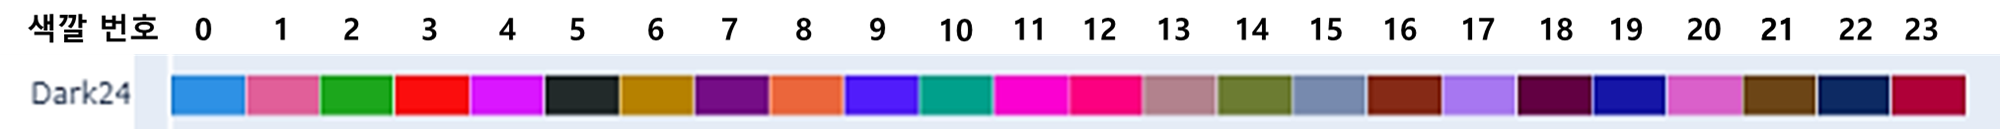

In [ ]:
# 데이터 세트 3차원 데이터 분석
# 애니메이션 구동 파라미터(천체 모양인 마커의 크기, 색깔 지정)
colors = px.colors.qualitative.Dark24
fig = px.scatter_3d(data_frame = dat_df_p_o_lb1_1, # 데이터 프레임에 '행성의 시간 데이터 세트' 열 대입
                    x="x", y="y", z='z', # x, y, z 입력값에 'x, y, z축' 열 대입
                    animation_frame="cal(TDB)", # 애니메이션 구동 기준에 '입력 시간 그레고리력' 열 대입
                    size='pr_label', ### <마커 크기에 '주요유형 레이블' 열 대입,
                                     ###  입력 가능한 열 이름: 'pr_label', 'dt_label'>
                    size_max=10, ### <마커 최대 크기 지정, 숫자 변경>
                    symbol='pr_class', ### <마커 기호에 '주요유형 레이블' 열 대입,
                                       ###  입력 가능한 열 이름: 'full_name', 'pr_class', 'dt_class'>
                    color='dt_class', ### <마커 색깔에 '세부유형 레이블' 열 대입,
                                      ###  입력 가능한 열 이름: 'full_name', 'pr_class', 'dt_class'>
                    color_discrete_map={'TP':colors[3], 'JP':colors[4], 'DP':colors[5],
                                        'APO':colors[6], 'AMO':colors[7], 'ATE':colors[8], 'IEO':colors[9],
                                        'MBA':colors[10], 'TJN':colors[11], 'TNO':colors[12],
                                        'Short-period_JFC':colors[13], 'Short-period_HTC':colors[14],'Long-period':colors[15]},
                                         ### <color='dt_class'일 때, 세부유형별로 매칭된 마커 색깔 지정, 위 색깔 표 참조하여 정수 입력>
                    hover_data=['pdes', 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y','pr_class', 'dt_class', 'neo', 'pha'],
                               ### <표시하려는 데이터 정보와 관련 열 대입,
                               ###  입력 가능한 열 이름: 'pdes', 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y','pr_class', 'dt_class', 'neo', 'pha'>
                    hover_name='full_name', # 마우스를 올렸을때 나타나는 이름에 '천체 명칭' 열 대입
                    # text='full_name' # 그림 위에 항상 표시되는 텍스트
                    )
# 태양 파라미터(태양 모양인 마커 크기, 색깔 지정)
fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], # 태양의 x, y, z 좌표 데이터 입력
                           mode='markers', # 3d 산점도 데이터의 표시 모드 종류 입력(마커)
                           marker=dict(color='orange', size=4, symbol='circle'), ### <마커 색깔, 크기 입력, 색깔 이름과 숫자 변경>
                           name='Sun' # 표시되는 명칭 입력
                           )
              )
### 아래 천체 궤도 선 파라미터에서 color=prdt_color[dt] 일 때 세부유형별로 매칭되는 색깔 변수 지정
prdt_color = {'TP':colors[3], 'JP':colors[4], 'DP':colors[5],
              'APO':colors[6], 'AMO':colors[7], 'ATE':colors[8], 'IEO':colors[9],
              'MBA':colors[10], 'TJN':colors[11], 'TNO':colors[12],
              'Short-period_JFC':colors[9], 'Short-period_HTC':colors[10],'Long-period':colors[5]}
              ### <궤도 선 표현시 세부유형별로 매칭된 색깔 지정, 위 색깔 표 참조하여 숫자 변경>
# 행성과 소천체 궤도 파라미터(궤도 선 폭, 색깔 지정)
for s in range(len(df_p_o_all1_1)):
  n = df_p_o_all1_1.loc[s, 'full_name'] # 천체의 명칭
  a = df_p_o_all1_1.loc[s, 'a'] # 천체의 장반경(태양과의 거리)(au)
  e = df_p_o_all1_1.loc[s, 'e'] # 천체의 이심률
  i = df_p_o_all1_1.loc[s, 'i'] # 천체의 경사각(황도면을 기준으로 기울어진 각도)(degree)
  om = df_p_o_all1_1.loc[s, 'om'] # 천체의 승교점 경도(황위가 -에서 +로 올라가면서 황도면과 교차하는 지점의 황경)(degree)
  w = df_p_o_all1_1.loc[s, 'w'] # 천체의 근일점 이각(승교점에서 근일점까지의 반시계방향(황경이 증가하는 방향의 이각)(degree)
  per_y = df_p_o_all1_1.loc[s, 'per_y']
  pr = df_p_o_all1_1.loc[s, 'pr_class'] # 천체의 주요유형
  dt = df_p_o_all1_1.loc[s, 'dt_class'] # 천체의 세부유형
  neo = df_p_o_all1_1.loc[s, 'neo'] # 천체의 근지구형 유무
  pha = df_p_o_all1_1.loc[s, 'pha'] # 천체의 지구위협형 유무
  r, x ,y, z = orbit_line(a, e, i, om, w, nps1) # 천체 궤도 선 산출 함수로 태양과의 거리, xyz 좌표 산출
  
  if pr == 'Planet': # 행성 궤도 파라미터
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, # 3d 산점도 xyz그래프
                              mode='lines', # 선 그리기 모드 지정
                              line=dict(color=prdt_color[dt], width=3),
                                        ### <선의 색 & 폭 지정, 폭은 숫자 변경
                                        ### 모든 천체를 각기 다른 색깔로 표현하기를 원하면: color=colors[s]
                                        ### 세부유형별로 매칭된 색깔로 표현하기를 원하면: color=prdt_color[dt]>
                              text=(pr+'_'+dt), # 표시되는 주석 입력(주요유형+세부유형 변수)
                              name=n # 표시되는 명칭 입력(명칭 변수)
                              )
                  )
  elif pr == 'Dwarfplanet': # 왜소행성 궤도 파라미터
    fig.add_trace(go.Scatter3d(x=x, y=y, z=z, # 3d 산점도 xyz그래프
                              mode='lines',
                              line=dict(color=prdt_color[dt], width=1),
                              text=(pr+'_'+dt),
                              name=n
                              )
                  )
  else:  # 소천체 궤도 파라미터
    fig.add_trace(go.Scatter3d(x=x, y=y,z=z, # 3d 산점도 xyz그래프
                              mode='lines',
                              line=dict(color=prdt_color[dt], width=1),
                              text=(pr+'_'+dt),
                              name=n
                              )
                  )
fig.update_layout(showlegend = True, ### <범례, False:표시, True:미표시>
                  font = dict(size=13), ### <그림에 표시되는 모든 글자의 크기, 숫자 변경>
                  width = 1500, ### <그림 너비, 숫자 변경>
                  height = 800, ### <그림 높이, 숫자 변경>
                  scene = dict(### <x, y, z 축의 경계값과 제목 설정>
                              xaxis = dict(range=[-100, 100], title='x (AU)'), ### <숫자변경, 글자변경>
                              yaxis = dict(range=[-100, 100], title='y (AU)'), ### <숫자변경, 글자변경>
                              zaxis = dict(range=[-100, 100], title='z (AU)'), ### <숫자변경, 글자변경>
                              aspectmode='cube' # 그림은 3차원의 정육면체 모양
                              )
                  )
fig.show() # 그림 출력

#### 2차원 궤도

In [ ]:
# 데이터 세트 2차원 데이터 분석 (X-Y축, 점 위치-Z축)
fig = go.Figure()
fig = make_subplots(rows=9, cols=4, # 9행 4열로 그래프를 분할하여 출력
                    horizontal_spacing=0.06,
                    vertical_spacing=0.03,
                    subplot_titles=('행성 x-y', '행성 points-z', '왜소행성 x-y', '왜소행성 points-z',
                                    '소행성 지구위협형 아모르 x-y', '소행성 지구위협형 아모르 points-z', '소행성 지구위협형 아폴로 x-y', '소행성 지구위협형 아폴로 points-z',
                                    '소행성 지구위협형 아텐 x-y', '소행성 지구위협형 아텐 points-z', '소행성 지구위협형 아티라 x-y', '소행성 지구위협형 아티라 points-z',               
                                    '소행성 근지구형 아모르 x-y', '소행성 근지구형 아모르 points-z', '소행성 근지구형 아폴로 x-y', '소행성 근지구형 아폴로 points-z',
                                    '소행성 근지구형 아텐 x-y', '소행성 근지구형 아텐 points-z', '소행성 근지구형 아티라 x-y', '소행성 근지구형 아티라 points-z',
                                    '소행성 주 소행성대형 x-y', '소행성 주 소행성대형 points-z', '소행성 목성 트로이군형 x-y', '소행성 목성 트로이군형 points-z',
                                    '소행성 해왕성 바깥 천체형 x-y', '소행성 해왕성 바깥 천체형 points-z', '혜성 근지구형(단주기) 목성 가족형 x-y', '혜성 근지구형(단주기) 목성 가족형 points-z',
                                    '혜성 근지구형(단주기) 헬리형 x-y', '혜성 근지구형(단주기) 헬리형 points-z', '혜성 단주기형 목성 가족형 x-y', '혜성 단주기형 목성 가족형 points-z',
                                    '혜성 단주기형 헬리형 x-y', '혜성 단주기형 헬리형 points-z', '혜성 장주기형 x-y', '혜성 장주기형 points-z')
                    )
e_n = [] # 지구_full_name
e_pr = [] # 지구_pr_class
e_x = [] # 지구_x축 궤도 좌표
e_y = [] # 지구_y축 궤도 좌표
m_n = [] # 화성_full_name
m_pr = [] # 화성_pr_class
m_x = [] # 화성_x축 궤도 좌표
m_y = [] # 화성_y축 궤도 좌표
j_n = [] # 목성_full_name
j_pr = [] # 목성_pr_class
j_x = [] # 목성_x축 궤도 좌표
j_y = [] # 목성_y축 궤도 좌표
n_n = [] # 해왕성_full_name
n_pr = [] # 해왕성_pr_class
n_x = [] # 해왕성_x축 궤도 좌표
n_y = [] # 해왕성_y축 궤도 좌표
# 행성과 소천체 궤도 파라미터
for s in range(len(df_p_o_all1_1)): # 행성+소천체 개수 만큼 반복
  n = df_p_o_all1_1.loc[s, 'full_name'] # 천체의 명칭
  a = df_p_o_all1_1.loc[s, 'a'] # 천체의 장반경(태양과의 거리)(au)
  e = df_p_o_all1_1.loc[s, 'e'] # 천체의 이심률
  i = df_p_o_all1_1.loc[s, 'i'] # 천체의 경사각(황도면을 기준으로 기울어진 각도)(degree)
  om = df_p_o_all1_1.loc[s, 'om'] # 천체의 승교점 경도(황위가 -에서 +로 올라가면서 황도면과 교차하는 지점의 황경)(degree)
  w = df_p_o_all1_1.loc[s, 'w'] # 천체의 근일점 이각(승교점에서 근일점까지의 반시계방향(황경이 증가하는 방향의 이각)(degree)
  pr = df_p_o_all1_1.loc[s, 'pr_class'] # 천체의 주요유형
  dt = df_p_o_all1_1.loc[s, 'dt_class'] # 천체의 세부유형
  neo = df_p_o_all1_1.loc[s, 'neo'] # 천체의 근지구형 유무
  pha = df_p_o_all1_1.loc[s, 'pha'] # 천체의 지구위협형 유무
  r, x ,y, z = orbit_line(a, e, i, om, w, nps1) # 천체 궤도 선 산출 함수로 태양과의 거리, xyz 좌표 산출
  if pr == 'Planet': # 행성 궤도 파라미터
    fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                             mode='lines',
                             text=(pr+'_'+dt),
                             name=n,
                             ),
                  row=1, col=1
                  )
    fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                             mode='lines',
                             text=(pr+'_'+dt),
                             name=n,
                             ),
                  row=1, col=2
                  )
    if n == 'Earth':
      e_n.append(n)
      e_pr.append(pr)
      e_x.append(x)
      e_y.append(y)
    if n == 'Mars':
      m_n.append(n)
      m_pr.append(pr)
      m_x.append(x)
      m_y.append(y)
    if n == 'Jupiter':
      j_n.append(n)
      j_pr.append(pr)
      j_x.append(x)
      j_y.append(y)
    if n == 'Neptune':
      n_n.append(n)
      n_pr.append(pr)
      n_x.append(x)
      n_y.append(y)
  elif pr == 'Dwarfplanet': # 왜소행성 궤도 파라미터
    fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                            mode='lines',
                            text=(pr+'_'+dt),
                            name=n,
                            ),
                  row=1, col=3
                  )
    fig.add_trace(go.Scatter(x=n_x[0], y=n_y[0], # 해왕성 x-y 기준 궤도 선 그래프
                            mode='lines',
                            line=dict(color='blue', width=5, dash='dash'),
                            text=n_pr[0],
                            name=n_n[0]
                            ),
                  row=1, col=3
                  )
    fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                            mode='lines',
                            text=(pr+'_'+dt),
                            name=n,
                            ),
                  row=1, col=4
                  )
  elif pr == 'Asteroid':
    if dt == 'AMO' and pha == 'Y':  # 소행성 중 지구위협형 아모르의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=2, col=1
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=2, col=1
                    )
      fig.add_trace(go.Scatter(x=m_x[0], y=m_y[0], # 화성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='green', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=2, col=1
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=2, col=2
                    )
    if dt == 'APO' and pha == 'Y':  # 소행성 중 지구위협형 아폴로의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=2, col=3
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=2, col=3
                    )
      fig.add_trace(go.Scatter(x=m_x[0], y=m_y[0], # 화성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='green', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=2, col=3
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=2, col=4
                    )
    if dt == 'ATE' and pha == 'Y':  # 소행성 중 지구위협형 아텐의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=3, col=1
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=3, col=1
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=3, col=2
                    )
    if dt == 'IEO' and pha == 'Y':  # 소행성 중 지구위협형 아티라의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=3, col=3
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=3, col=3
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=3, col=4
                    )
    if dt == 'AMO' and pha == 'N':  # 소행성 중 근지구형 아모르의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=4, col=1
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=4, col=1
                    )
      fig.add_trace(go.Scatter(x=m_x[0], y=m_y[0], # 화성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='green', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=4, col=1
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=4, col=2
                    )
    if dt == 'APO' and pha == 'N':  # 소행성 중 근지구형 아폴로의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=4, col=3
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=4, col=3
                    )
      fig.add_trace(go.Scatter(x=m_x[0], y=m_y[0], # 화성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='green', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=4, col=3
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=4, col=4
                    )
    if dt == 'ATE' and pha == 'N':  # 소행성 중 근지구형 아텐의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=5, col=1
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=5, col=1
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=5, col=2
                    )
    if dt == 'IEO' and pha == 'N':  # 소행성 중 근지구형 아티라의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=5, col=3
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=5, col=3
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=5, col=4
                    )
    if dt == 'MBA': # 소행성 중 주 소행성대형의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=6, col=1
                    )
      fig.add_trace(go.Scatter(x=m_x[0], y=m_y[0], # 화성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='green', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=6, col=1
                    )
      fig.add_trace(go.Scatter(x=j_x[0], y=j_y[0], # 목성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='blue', width=5, dash='dash'),
                              text=j_pr[0],
                              name=j_n[0]
                              ),
                    row=6, col=1
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=6, col=2
                    )
    if dt == 'TJN': # 소행성 중 목성 트로이형의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=6, col=3
                    )
      fig.add_trace(go.Scatter(x=j_x[0], y=j_y[0], # 목성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='blue', width=5, dash='dash'),
                              text=j_pr[0],
                              name=j_n[0]
                              ),
                    row=6, col=3
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=6, col=4
                    )
    if dt == 'TNO': # 소행성 중 해왕성 바깥 천체형의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=7, col=1
                    )
      fig.add_trace(go.Scatter(x=n_x[0], y=n_y[0], # 해왕성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='black', width=5, dash='dash'),
                              text=n_pr[0],
                              name=n_n[0]
                              ),
                    row=7, col=1
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=7, col=2
                    )
  elif pr == 'Comet':
    if dt == 'Short-period_JFC' and neo == 'Y': # 혜성 중 근지구형(단주기) 목성 가족형의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=7, col=3
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=7, col=3
                    )    
      fig.add_trace(go.Scatter(x=j_x[0], y=j_y[0], # 목성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='blue', width=5, dash='dash'),
                              text=j_pr[0],
                              name=j_n[0]
                              ),
                    row=7, col=3
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=7, col=4
                    )
    if dt == 'Short-period_HTC' and neo == 'Y': # 혜성 중 근지구형(단주기) 헬리형의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=8, col=1
                    )
      fig.add_trace(go.Scatter(x=e_x[0], y=e_y[0], # 지구 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='red', width=5, dash='dash'),
                              text=e_pr[0],
                              name=e_n[0]
                              ),
                    row=8, col=1
                    )                    
      fig.add_trace(go.Scatter(x=j_x[0], y=j_y[0], # 목성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='blue', width=5, dash='dash'),
                              text=j_pr[0],
                              name=j_n[0]
                              ),
                    row=8, col=1
                    )
      fig.add_trace(go.Scatter(x=n_x[0], y=n_y[0], # 해왕성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='black', width=5, dash='dash'),
                              text=n_pr[0],
                              name=n_n[0]
                              ),
                    row=8, col=1
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=8, col=2
                    )    
    if dt == 'Short-period_JFC' and neo == 'N': # 혜성 중 단주기형 목성 가족형의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=8, col=3
                    )
      fig.add_trace(go.Scatter(x=j_x[0], y=j_y[0], # 목성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='blue', width=5, dash='dash'),
                              text=j_pr[0],
                              name=j_n[0]
                              ),
                    row=8, col=3
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=8, col=4
                    )
    if dt == 'Short-period_HTC' and neo == 'N': # 혜성 중 단주기형 헬리형의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=9, col=1
                    )
      fig.add_trace(go.Scatter(x=j_x[0], y=j_y[0], # 목성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='blue', width=5, dash='dash'),
                              text=j_pr[0],
                              name=j_n[0]
                              ),
                    row=9, col=1
                    )
      fig.add_trace(go.Scatter(x=n_x[0], y=n_y[0], # 해왕성 x-y 기준 궤도 선 그래프
                              mode='lines',
                              line=dict(color='black', width=5, dash='dash'),
                              text=n_pr[0],
                              name=n_n[0]
                              ),
                    row=9, col=1
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=9, col=2
                    )
    if dt == 'Long-period' : # 혜성 중 장주기형의 궤도 파라미터
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=9, col=3
                    )
      fig.add_trace(go.Scatter(x=np.arange(nps1), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                              mode='lines',
                              text=(pr+'_'+dt),
                              name=n,
                              ),
                    row=9, col=4
                    )
# fig.update_traces(line=dict(color='blue', width=1)) # 모든 그래프에 동일한 선 색깔, 너비 적용
fig.update_xaxes(title_text="x", range=(-35, 35), row=1, col=1) # 행성 x-y
fig.update_yaxes(title_text="y", range=(-35, 35), row=1, col=1)
fig.update_xaxes(title_text="points", row=1, col=2) # 행성 points-z
fig.update_yaxes(title_text="z", row=1, col=2)
fig.update_xaxes(title_text="x", range=(-100, 100), row=1, col=3) # 왜소행성 x-y
fig.update_yaxes(title_text="y", range=(-100, 100), row=1, col=3)
fig.update_xaxes(title_text="points", row=1, col=4) # 왜소행성 points-z
fig.update_yaxes(title_text="z", row=1, col=4)
fig.update_xaxes(title_text="x", range=(-5, 5), row=2, col=1) # 소행성 지구위협형 아모르 x-y
fig.update_yaxes(title_text="y", range=(-5, 5), row=2, col=1)
fig.update_xaxes(title_text="points", row=2, col=2) # 소행성 지구위협형 아모르 points-z
fig.update_yaxes(title_text="z", row=2, col=2)
fig.update_xaxes(title_text="x", range=(-5, 5), row=2, col=3) # 소행성 지구위협형 아폴로 x-y
fig.update_yaxes(title_text="y", range=(-5, 5), row=2, col=3)
fig.update_xaxes(title_text="points", row=2, col=4) # 소행성 지구위협형 아폴로 points-z
fig.update_yaxes(title_text="z", row=2, col=4)
fig.update_xaxes(title_text="x", range=(-2, 2), row=3, col=1) # 소행성 지구위협형 아텐 x-y
fig.update_yaxes(title_text="y", range=(-2, 2), row=3, col=1)
fig.update_xaxes(title_text="points", row=3, col=2) # 소행성 지구위협형 아텐 points-z
fig.update_yaxes(title_text="z", row=3, col=2)
fig.update_xaxes(title_text="x", range=(-2, 2), row=3, col=3) # 소행성 지구위협형 아티라 x-y
fig.update_yaxes(title_text="y", range=(-2, 2), row=3, col=3)
fig.update_xaxes(title_text="points", row=3, col=4) # 소행성 지구위협형 아티라 points-z
fig.update_yaxes(title_text="z", row=3, col=4)
fig.update_xaxes(title_text="x", range=(-5, 5), row=4, col=1) # 소행성 근지구형 아모르 x-y
fig.update_yaxes(title_text="y", range=(-5, 5), row=4, col=1)
fig.update_xaxes(title_text="points", row=4, col=2) # 소행성 근지구형 아모르 points-z
fig.update_yaxes(title_text="z", row=4, col=2)
fig.update_xaxes(title_text="x", range=(-5, 5), row=4, col=3) # 소행성 근지구형 아폴로 x-y
fig.update_yaxes(title_text="y", range=(-5, 5), row=4, col=3)
fig.update_xaxes(title_text="points", row=4, col=4) # 소행성 근지구형 아폴로 points-z
fig.update_yaxes(title_text="z", row=4, col=4)
fig.update_xaxes(title_text="x", range=(-2, 2), row=5, col=1) # 소행성 근지구형 아텐 x-y
fig.update_yaxes(title_text="y", range=(-2, 2), row=5, col=1)
fig.update_xaxes(title_text="points", row=5, col=2) # 소행성 근지구형 아텐 points-z
fig.update_yaxes(title_text="z", row=5, col=2)
fig.update_xaxes(title_text="x", range=(-2, 2), row=5, col=3) # 소행성 근지구형 아티라 x-y
fig.update_yaxes(title_text="y", range=(-2, 2), row=5, col=3)
fig.update_xaxes(title_text="points", row=5, col=4) # 소행성 근지구형 아티라 points-z
fig.update_yaxes(title_text="z", row=5, col=4)
fig.update_xaxes(title_text="x", range=(-6, 6), row=6, col=1) # 소행성 주 소행성대형 x-y
fig.update_yaxes(title_text="y", range=(-6, 6), row=6, col=1)
fig.update_xaxes(title_text="points", row=6, col=2) # 소행성 주 소행성대형 points-z
fig.update_yaxes(title_text="z", row=6, col=2)
fig.update_xaxes(title_text="x", range=(-8, 8), row=6, col=3) # 소행성 목성 트로이형 x-y
fig.update_yaxes(title_text="y", range=(-8, 8), row=6, col=3)
fig.update_xaxes(title_text="points", row=6, col=4) # 소행성 목성 트로이군형 points-z
fig.update_yaxes(title_text="z", row=6, col=4)
fig.update_xaxes(title_text="x", range=(-980, 980), row=7, col=1) # 소행성 해왕성 바깥 천체형 x-y
fig.update_yaxes(title_text="y", range=(-980, 980), row=7, col=1)
fig.update_xaxes(title_text="points", row=7, col=2) # 소행성 해왕성 바깥 천체형 points-z
fig.update_yaxes(title_text="z", row=7, col=2)
fig.update_xaxes(title_text="x", range=(-15, 15), row=7, col=3) # 혜성 근지구형(단주기) 목성 가족형 x-y
fig.update_yaxes(title_text="y", range=(-15, 15), row=7, col=3)
fig.update_xaxes(title_text="points", row=7, col=4) # 혜성 근지구형(단주기) 목성 가족형 points-z
fig.update_yaxes(title_text="z", row=7, col=4)
fig.update_xaxes(title_text="x", range=(-50, 50), row=8, col=1) # 혜성 근지구형(단주기) 헬리형 x-y
fig.update_yaxes(title_text="y", range=(-50, 50), row=8, col=1)
fig.update_xaxes(title_text="points", row=8, col=2) # 혜정 근지구형(단주기) 헬리형 points-z
fig.update_yaxes(title_text="z", row=8, col=2)
fig.update_xaxes(title_text="x", range=(-15, 15), row=8, col=3) # 혜성 단주기형 목성 가족형 x-y
fig.update_yaxes(title_text="y", range=(-15, 15), row=8, col=3)
fig.update_xaxes(title_text="points", row=8, col=4) # 혜성 단주기형 목성 가족형 points-z
fig.update_yaxes(title_text="z", row=8, col=4)
fig.update_xaxes(title_text="x", range=(-50, 50), row=9, col=1) # 혜성 단주기형 헬리형 x-y
fig.update_yaxes(title_text="y", range=(-50, 50), row=9, col=1)
fig.update_xaxes(title_text="points", row=9, col=2) # 혜정 단주기형 헬리형 points-z
fig.update_yaxes(title_text="z", row=9, col=2)
fig.update_xaxes(title_text="x", row=9, col=3) # 혜성 장주기형 x-y
fig.update_yaxes(title_text="y", row=9, col=3)
fig.update_xaxes(title_text="points", row=9, col=4) # 혜정 장주기형 points-z
fig.update_yaxes(title_text="z", row=9, col=4)
fig.update_layout(showlegend=False,
                  font = dict(size=13),
                  width = 1500,
                  height = 3150,
                  #hovermode='x unified'
                  ),
fig.show()

### 그래프 분석

#### 상자 수염 그래프 - 구성, 비중 분포 시각화(분포 분석)

In [ ]:
'''
상자 수염(박스) 그래프
● 범주형(가로축에 범주형 속성) &
● 수치형(세로축에 수치형 속성) 

<data_frame에 입력 가능한 데이터 세트: 
 [df: 모든 천체, df_p: 모든 행성, df_p_1: 지구형 행성, df_p_2: 목성형 행성. df_d: 왜소행성]
 [df_a: 모든 소행성, df_a_0: 모든 지구위협형, df_a_1: 모든 근지구형, df_a_2: 주 소행성대형, df_a_3: 목성 트로이군형, df_a_4: 해왕성 바깥 천체형]
 [df_c: 모든 혜성, df_c_1: 모든 근지구형, df_c_2: 모든 단주기형, df_c_3: 단주기 목성 가족형, df_c_4: 단주기 헬리형, df_c_5: 장주기형]>
<x에 입력 가능한 범주형 열(속성) 이름: 'pr_class', 'dt_class', 'neo', 'pha'>
<y에 입력 가능한 수치형 열(속성) 이름: 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'>
<color에 입력 가능한 열(속성) 이름: 'pr_class', 'dt_class', 'neo', 'pha'>
<facet_col(x축 기준)에 입력 가능한 열(속성) 이름: None, 'pr_class', 'dt_class', 'neo', 'pha'>
<facet_col(y축 기준)에 입력 가능한 열(속성) 이름: None, 'pr_class', 'dt_class', 'neo', 'pha'>
<y축 상용로그 값으로 변환: log_y = False -> log_y = True>
<boxmode 가능한 종류: 'group', 'overlay'>
<size: 글자크기 숫자 변경, widht: 그림 폭 숫자 변경, height: 그림 높이 숫자 변경>
'''
fig = px.box(data_frame=df_p_o_all1, x='pr_class', y='a', log_y=True, color='pr_class', facet_col=None, facet_row=None, points="all", boxmode='overlay',
             hover_data=['q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y', 'pr_class', 'dt_class', 'neo', 'pha'], hover_name='full_name',)
fig.update_traces(boxmean=True)
fig.update_layout(font=dict(size=15), width=1300,  height=500)
fig.show()

#### 막대 그래프 - 비교 시각화

In [ ]:
'''
막대 그래프 
● 범주형(가로축에 범주형 속성) & 
● 수치형(세로축에 데이터 크기나 빈도수)
(범주형 열(속성)의 분위수를 제외한 빈도수, 합계, 평균값, 최솟값, 최댓값 분석)
(추가 기능으로, 세로 열에 수치형 속성(열)을 추가하면 각 범주형 마다 수치형의 대푯값 계산)

<data_frame에 입력 가능한 데이터 세트: 
 [df: 모든 천체, df_p: 모든 행성, df_p_1: 지구형 행성, df_p_2: 목성형 행성. df_d: 왜소행성]
 [df_a: 모든 소행성, df_a_0: 모든 지구위협형, df_a_1: 모든 근지구형, df_a_2: 주 소행성대형, df_a_3: 목성 트로이군형, df_a_4: 해왕성 바깥 천체형]
 [df_c: 모든 혜성, df_c_1: 모든 근지구형, df_c_2: 모든 단주기형, df_c_3: 단주기 목성 가족형, df_c_4: 단주기 헬리형, df_c_5: 장주기형]>
<x에 입력 가능한 열(속성) 이름: 'pr_class', 'dt_class', 'nea', 'pha'>
<y에 추가로 입력 가능한 열(속성) 이름: None, 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'>
<color에 입력 가능한 열(속성) 이름: 'pr_class', 'dt_class', 'neo', 'pha'>
<facet_col(x축 기준)에 입력 가능한 열(속성) 이름: None, 'pr_class', 'dt_class', 'neo', 'pha'>
<facet_col(y축 기준)에 입력 가능한 열(속성) 이름: None, 'pr_class', 'dt_class', 'neo', 'pha'>
<histfunc에 입력가능한 대푯값(y열에 수치형 열이 입력될때만 작동): 'count', 'sum', 'avg', 'max', 'min'>
<y축 로그 값으로 변환: log_y = False -> log_y = True>
<barome 가능한 종류: 'group', 'relative', 'overlay'>
<size: 글자크기 숫자 변경, widht: 그림 폭 숫자 변경, height: 그림 높이 숫자 변경>
'''
fig = px.histogram(data_frame=df_p_o_all1, x='pr_class', y='a', log_y=True, color='pr_class', facet_col=None, facet_row=None,
                   histfunc='max', barmode='relative', text_auto=True)
fig.update_layout(font=dict(size=15), width=1300,  height=500)
fig.show()

#### 산점도 - 관계 시각화

In [ ]:
'''
기존의 전체 혜성 데이터 세트 중 천체명, 장반경, 이심률, 경사각, 목성 티세랑,
공전 주기(년), 세부 유형으로만 구성된 새 데이터 세트 생성

'''
df_tj_c = pd.DataFrame({'full_name': df_c['full_name'], # 새 데이터 세트의 full_name에 기존의 혜성 데이터 세트의 천체명 대입
                        'q': df_c['q'], # 새 데이터 세트의 q에 기존의 혜성 데이터 세트의 근일점 대입
                        'ad': df_c['ad'], # 새 데이터 세트의 ad에 기존의 혜성 데이터 세트의 원일점 대입
                        'a': df_c['a'], # 새 데이터 세트의 a에 기존의 혜성 데이터 세트의 장반경 대입
                        'x': 1/df_c['a'], # 새 데이터 세트의 x에 기존의 혜성 데이터 세트의 1/장반경 대입
                        'e': df_c['e'], # 새 데이터 세트의 e에 기존의 혜성 데이터 세트의 이심률 대입
                        'i': df_c['i'], # 새 데이터 세트의 i에 기존의 혜성 데이터 세트의 궤도 경사각 대입
                        'om': df_c['om'], # 새 데이터 세트의 om에 기존의 혜성 데이터 세트의 승교점 경도 대입
                        'w':df_c['w'], # 새 데이터 세트의 w에 기존의 혜성 데이터 세트의 근일점 이각 대입
                        't_jup': df_c['t_jup'], # 새 데이터 세트의 t_jup에 기존의 혜성 데이터 세트의 목성 티세랑 대입
                        'per_y': df_c['per_y'], # 새 데이터 세트의 per_y에 기존의 혜성 데이터 세트의 공전주기(년) 대입
                        'class': df_c['dt_class']}) # 새 데이터 세트의 class에 기존의 혜성 데이터 세트의 세부유형 대입
df_tj_c = df_tj_c.reset_index(drop=True) # 인덱스 숫자를 0부터 시작하는 오름차수로 조정
display(df_tj_c)

In [ ]:
'''
전체 혜성 데이터 세트의 목성 티세랑 비교
'''
fig = px.scatter(data_frame=df_tj_c, x='x', y='t_jup', log_x=False, color='class', symbol='class', marginal_x="rug", # marginal_y='histrogram',  'rug', 'box', 'violin'
                 hover_data=['q', 'ad', 'a', 'x','e', 'i', 'om', 'w', 'per_y', 'class', 't_jup'], hover_name='full_name')  # range_x=[0,50]
fig.add_hline(y=2.0, line_dash="dot", line_width=3, line_color='green', annotation_text="t_jup2", annotation_position="bottom right")
fig.add_vrect(x0=0, x1=0.03, line_width=0, annotation_text="Period(year) > 200", annotation_position="top")
fig.add_vrect(x0=0.03, x1=0.1345618, line_width=0, fillcolor="red", opacity=0.2, annotation_text="20 < Period(year) < 200", annotation_position="top")
fig.add_vrect(x0=0.1345618, x1=0.4, line_width=0, annotation_text="Period(year) < 20", annotation_position="top")
fig.show()

In [ ]:
'''
산점도
● 수치형(가로축에 수치형 속성) &
● 수치형(세로축에 수치형 속성) 

<data_frame에 입력 가능한 데이터 세트: 
 [df: 모든 천체, df_p: 모든 행성, df_p_1: 지구형 행성, df_p_2: 목성형 행성. df_d: 왜소행성]
 [df_a: 모든 소행성, df_a_0: 모든 지구위협형, df_a_1: 모든 근지구형, df_a_2: 주 소행성대형, df_a_3: 목성 트로이군형, df_a_4: 해왕성 바깥 천체형]
 [df_c: 모든 혜성, df_c_1: 모든 근지구형, df_c_2: 모든 단주기형, df_c_3: 단주기 목성 가족형, df_c_4: 단주기 헬리형, df_c_5: 장주기형]>
<x에 입력 가능한 수치형 열(속성) 이름: 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'>
<y에 입력 가능한 수치형 열(속성) 이름: 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid',  'per', 'per_y'>
<color에 입력 가능한 열(속성) 이름: 'pr_class', 'dt_class', 'neo', 'pha'>
<symbol에 입력 가능한 열(속성) 이름: 'pr_class', 'dt_class', 'neo', 'pha'>
<facet_col(x축 기준)에 입력 가능한 열(속성) 이름: None, 'pr_class', 'dt_class', 'neo', 'pha'>
<facet_col(y축 기준)에 입력 가능한 열(속성) 이름: None, 'pr_class', 'dt_class', 'neo', 'pha'>
<x축 로그 값으로 변환: log_x = False -> log_x = True>
<y축 로그 값으로 변환: log_y = False -> log_y = True>
<x축 범위 제한: range_x=[시작값, 끝값]> (단, 시작값을 0으로 하면 log 변환이 안됨)
<y축 범위 제한: range_y=[시작값, 끝값]> (단, 시작값을 0으로 하면 log 변환이 안됨)
<marginal 가능한 종류: 'histrogram', 'rug', 'box', 'violin'>
<size: 글자크기 숫자 변경, widht: 그림 폭 숫자 변경, height: 그림 높이 숫자 변경>
'''
fig = px.scatter(data_frame=df_p_o_all1, x='a', y='e', log_x=True, log_y=False, color='pr_class', symbol='pr_class',  facet_col=None, facet_row=None, marginal_x="rug",
                 hover_data=['q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y', 'pr_class', 'dt_class', 'neo', 'pha'], hover_name='full_name', 
                 range_x=None, range_y=None)
# 옵션: 목성 티세랑 2와 3 선택 * 산점도 그래프 위에 표시 하고 싶으면 코드 옆 # 삭제
# fig.add_traces(list(px.line(df_tj2_3, x='a', y='e', color='name', line_dash='name', hover_name='name').select_traces()))
fig.update_layout(font=dict(size=15), width=1300,  height=500)
fig.show()

## **데이터 세트 천체 분석 마우스 클릭형**

### 그래프 분석

#### 상자 수염 그래프 - 구성, 비중 분포 시각화(분포 분석)

In [ ]:
#@title 상자 수염 그래프 — Colab 대화형 입력
box_dfs = "df" #@param ["df","df_p","df_p_1","df_p_2","df_d","df_a","df_a_0","df_a_1","df_a_2","df_a_3","df_a_4","df_c","df_c_1","df_c_2","df_c_3","df_c_4","df_c_5"]
box_x = "pr_class" #@param ["pr_class","dt_class"]
box_y = "a" #@param ["q","ad","a","e","i","om","w","t_jup","moid","per","per_y"]
box_log_y = False #@param {type:"boolean"}
box_color = "pr_class" #@param ["pr_class","dt_class","neo","pha"]
box_facet_x = "None" #@param ["None","pr_class","dt_class","neo","pha"]
box_facet_y = "None" #@param ["None","pr_class","dt_class","neo","pha"]
boxmode = "group" #@param ["group","overlay"]

df_input = dataframe_input(box_dfs)
fig = px.box(
    data_frame=df_input, x=box_x, y=box_y, log_y=box_log_y, color=box_color,
    points="all", boxmode=boxmode,
    hover_data=['q','ad','a','e','i','om','w','t_jup','moid','pr_class','dt_class','neo','pha'],
    hover_name='full_name',
    facet_col=None if box_facet_x == 'None' else box_facet_x,
    facet_row=None if box_facet_y == 'None' else box_facet_y
)
fig.update_traces(boxmean=True)
fig.update_layout(font=dict(size=15), width=1100, height=500)
fig.show()


#### 막대 그래프 - 비교 시각화

In [ ]:
#@title 막대 그래프 — Colab 대화형 입력
bar_dfs = "df" #@param ["df","df_p","df_p_1","df_p_2","df_d","df_a","df_a_0","df_a_1","df_a_2","df_a_3","df_a_4","df_c","df_c_1","df_c_2","df_c_3","df_c_4","df_c_5"]
bar_x = "pr_class" #@param ["pr_class","dt_class","neo","pha"]
bar_y = "None" #@param ["None","q","ad","a","e","i","om","w","t_jup","moid","per","per_y"]
bar_log_y = False #@param {type:"boolean"}
bar_color = "pr_class" #@param ["pr_class","dt_class","neo","pha"]
bar_facet_x = "None" #@param ["None","pr_class","dt_class","neo","pha"]
bar_facet_y = "None" #@param ["None","pr_class","dt_class","neo","pha"]
histfunc = "count" #@param ["count","sum","avg","max","min"]
barmode = "relative" #@param ["group","relative","overlay"]

df_input = dataframe_input(bar_dfs)
fig = px.histogram(
    data_frame=df_input, x=bar_x, y=None if bar_y == 'None' else bar_y,
    log_y=bar_log_y, color=bar_color, histfunc=histfunc, barmode=barmode, text_auto=True,
    facet_col=None if bar_facet_x == 'None' else bar_facet_x,
    facet_row=None if bar_facet_y == 'None' else bar_facet_y
)
fig.update_layout(font=dict(size=15), width=1100, height=500)
fig.show()


#### 산점도 - 관계 시각화

In [ ]:
#@title 산점도 — Colab 대화형 입력
scatter_dfs = "df" #@param ["df","df_p","df_p_1","df_p_2","df_d","df_a","df_a_0","df_a_1","df_a_2","df_a_3","df_a_4","df_c","df_c_1","df_c_2","df_c_3","df_c_4","df_c_5"]
scatter_x = "a" #@param ["q","ad","a","e","i","om","w","t_jup","moid","per","per_y"]
scatter_y = "e" #@param ["q","ad","a","e","i","om","w","t_jup","moid","per","per_y"]
scatter_log_x = False #@param {type:"boolean"}
scatter_log_y = False #@param {type:"boolean"}
scatter_color = "pr_class" #@param ["pr_class","dt_class","neo","pha"]
scatter_facet_x = "None" #@param ["None","pr_class","dt_class","neo","pha"]
scatter_facet_y = "None" #@param ["None","pr_class","dt_class","neo","pha"]
marginal_x = "rug" #@param ["rug","box","violin","histogram"]
marginal_y = "rug" #@param ["rug","box","violin","histogram"]
show_tj_boundary = False #@param {type:"boolean"}
start_x = None #@param {type:"number"}
finish_x = None #@param {type:"number"}
start_y = None #@param {type:"number"}
finish_y = None #@param {type:"number"}

df_input = dataframe_input(scatter_dfs)
range_x = None if start_x is None or finish_x is None else [start_x, finish_x]
range_y = None if start_y is None or finish_y is None else [start_y, finish_y]
fig = px.scatter(
    data_frame=df_input, range_x=range_x, range_y=range_y,
    x=scatter_x, log_x=scatter_log_x, y=scatter_y, log_y=scatter_log_y,
    color=scatter_color, symbol=scatter_color, marginal_x=marginal_x, marginal_y=marginal_y,
    hover_data=['q','ad','a','e','i','om','w','t_jup','moid','pr_class','dt_class','neo','pha'],
    hover_name='full_name',
    facet_col=None if scatter_facet_x == 'None' else scatter_facet_x,
    facet_row=None if scatter_facet_y == 'None' else scatter_facet_y
)
if show_tj_boundary and scatter_x == 'a' and scatter_y == 'e':
    fig.add_traces(list(px.line(jupiter_tisserand(), x='a', y='e', color='name', line_dash='name', hover_name='name').select_traces()))
fig.update_layout(font=dict(size=15), width=1100, height=500)
fig.show()


# **데이터 분석 및 표현 [천체 X의 분류 유형 찾기]**

## **개별 천체 분석 코드 입력형**

### 분석 점 개수 입력

In [ ]:
'''
평균 이각 계산을 위한 점 개수 지정
점 개수가 많을수록 궤도 선은 정밀해지지만, 컴퓨터 부하를 증가시키도 합니다.
101개~801개 사이 입력을 권합니다.
'''
nps = 601 

In [ ]:
'''
장반경: 0~40 au, 이심률: 0~1, 경사각: 0일의 목성 티세랑(juvian tisserand, Tj) 함수 실행
'''
df_tj2_3 = jupiter_tisserand()

### 분석 시간 입력

In [ ]:
'''
분석 시작 시간 입력(단위: 그레고리력)
입력값이 없을 시 기본값으로 "2023-06-01 12:00:00" 자동 입력
'''
s_t = str(input('분석 시작 날짜를 입력하세요(UTC 기준).(예: 2023-06-01 12:00:00): ') or "2023-06-01 12:00:00")
print(s_t)
s_jd = Time(s_t, format='iso', scale='utc').jd # 율리우스력 일로 변환

In [ ]:
'''
분석 종료 시간 입력(단위: 그레고리력)
입력값이 없을 시 기본값으로 "2023-06-02 12:00:00" 자동 입력
'''
f_t = str(input('분석 종료 날짜를 입력하세요(UTC 기준).(예: 2023-06-02 12:00:00): ') or "2023-06-02 12:00:00")
print(f_t)
f_jd = Time(f_t, format='iso', scale='utc').jd # 율리우스력 일로 변환

In [ ]:
'''
분석 시간 간격 입력(단위: 시간)
입력값이 없을 시 기본값으로 "24" 자동 입력
'''
t_h = float(input('분석 시간 간격을 시간 단위로 입력하세요.(예: 30분: 0.5시간, 1시간: 1시간, 1일: 24시간, 1달: 720시간 또는 744시간, 1년: 8760 또는 8766시간): ') or "24")
print(t_h)
t_d = t_h/24 # 입력된 시간 간격을 24시간으로 나눠 일 수로 변환

### 분석 천체 입력

In [ ]:
'''
소천체의 식별번호(pes) 입력
아무것도 입력하지 않을시 8대 행성만 분석합니다.
'''
o_pdes_list = input('분석하고자 하는 천체의 식별번호(pdes)를 콤마를 구분자로하여 입력하세요.(예:1P, 1): ').split(', ')

### 입력된 천체의 궤도 정보와 시간이 포함된 데이터 세트 생성

In [ ]:
for pdes in o_pdes_list:
  df_o = df[ df['pdes'] == pdes ] # df 데이터 세트에서 입력된 소천체의 기본명칭을 갖는 데이터 추출
  df_o_1 = df_o[df_o.pr_class != 'Satellite'] # 위 데이터 세트에서 주요 유형이 Satellite(위성)가 아닌 데이터만 다시 추출
  dat_df_o = object_datetimeframe(df_o_1, s_jd, f_jd, t_d) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 소천체의 시간 데이터 세트 산출
  dat_df_p = planet_datetimeframe(s_jd, f_jd, t_d) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 행성의 시간 데이터 세트 산출
  if pdes == o_pdes_list[0]:
    dat_df_p_o = dataframe_concatenate(dat_df_p, dat_df_o) # 행성의 시간 데이터 세트와 소천체의 시간 데이터 세트 합치기
    df_p_o = dataframe_concatenate(df_p, df_o) # 행성의 데이터 세트와 소천체의 데이터 세트 합치기
  else:
    dat_df_p_o = dataframe_concatenate(dat_df_p_o, dat_df_o)
    df_p_o = dataframe_concatenate(df_p_o, df_o)
df_p_o_all = df_p_o # 시간 데이터 세트 없이 행성과 분석하고자 하는 천체의 정보가 합쳐진 데이터 세트
df_p_o_all_1 = df_p_o_all[df_p_o_all.pr_class != 'Satellite'] # 시간 데이터 세트가 없으며, 위성 정보도 없는 행성과 분석하고자 하는 천체의 정보가 합쳐진 데이터 세트
df_p_o_all_2 = df_p_o_all_1.iloc[:, 0:14]
dat_df_p_o_lb_1 = pr_dt_class_labelencoder(dat_df_p_o) # 위성 정보는 없는, 합쳐진 시간 데이터 세트의 주요유형과 세부유형의 문자형 데이터를 숫자형으로 레이블 변환
dat_df_p_o_lb_2 = dat_df_p_o_lb_1.drop(columns='pr_class')
dat_df_p_o_lb_3 = dat_df_p_o_lb_2.drop(columns='dt_class')
dat_df_p_o_lb_4 = dat_df_p_o_lb_3.drop(columns='neo')
dat_df_p_o_lb_5 = dat_df_p_o_lb_4.drop(columns='pha')
dat_df_p_o_lb_6 = dat_df_p_o_lb_5.drop(columns='pr_label')
dat_df_p_o_lb_7 = dat_df_p_o_lb_6.drop(columns='dt_label')
condition = dat_df_p_o_lb_1 ['pr_class'] == 'Planet'
dat_df_p_o_lb_7.loc[condition, 'code'] = 2
dat_df_p_o_lb_7.loc[~condition, 'code'] = 1
display(dat_df_p_o_lb_7) # 데이터 세트 출력

### 궤도 분석

#### 3차원 궤도

> 아래 코드 셀을 실행하면 원본 실습의 **대화형 Plotly 궤도 그래프**가 직접 생성됩니다.  
> Colab에서는 정적인 예시 스크린샷 대신 실행 결과를 확대·회전하며 확인하세요.


In [ ]:
# 3차원 궤도 분석

# 천체 애니메이션 구동 파라미터와 천체 궤도선 파라미터에 적용될 색깔 변수 지정
colors = px.colors.qualitative.Dark24 # 24가지 색깔 모음, 색깔 순서는 위 색깔 번호표 참조

### 천체 애니메이션 구동 파라미터(천체 모양인 마커의 크기, 색깔, 기호 종류 설정 및 데이터 표시 정보 지정)
fig = px.scatter_3d(data_frame = dat_df_p_o_lb_7, # 데이터 프레임에 '행성와 개별 소천체의 시간 데이터 세트' 열 대입
                    x="x", y="y", z='z', # x, y, z 입력값에 'x, y, z축' 열 대입
                    animation_frame="cal(TDB)", # 애니메이션 구동 기준에 '입력 시간 그레고리력' 열 대입
                    size='code', # 마커 사이즈
                    size_max=10, ### <마커 최대 크기 지정, 숫자 변경>
                    hover_data=['pdes', 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'],
                               ### <표시하려는 데이터 정보와 관련 열 대입,
                               ###  입력 가능한 열 이름: 'pdes', 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'>
                    hover_name='full_name', # 마우스를 올렸을때 나타나는 이름에 '천체 명칭' 열 대입
                    text='full_name' # 그림 위에 항상 표시되는 텍스트
                    )
### 태양 파라미터(태양 모양인 마커 크기, 색깔 설정)
fig.add_trace(go.Scatter3d(x=[0], y=[0], z=[0], # 태양의 x, y, z 좌표 데이터 입력
                           mode='markers', # 3d 산점도 데이터의 표시 모드 종류 입력(마커)
                           marker=dict(color='orange', size=4), ### <마커 색깔 & 크기 입력, 색깔은 영문 입력, 크기는 정수 입력>
                           name='Sun' # 표시되는 명칭 입력
                           )
              )
### 천체 궤도 선 파라미터(천체 궤도 선 폭, 색깔 설정)
for s in range(len(df_p_o_all_1)):
  n = df_p_o_all_1.loc[s, 'full_name'] # 천체의 명칭
  a = df_p_o_all_1.loc[s, 'a'] # 천체의 장반경(태양과의 거리)(au)
  e = df_p_o_all_1.loc[s, 'e'] # 천체의 이심률
  i = df_p_o_all_1.loc[s, 'i'] # 천체의 경사각(황도면을 기준으로 기울어진 각도)(degree)
  om = df_p_o_all_1.loc[s, 'om'] # 천체의 승교점 경도(황위가 -에서 +로 올라가면서 황도면과 교차하는 지점의 황경)(degree)
  w = df_p_o_all_1.loc[s, 'w'] # 천체의 근일점 이각(승교점에서 근일점까지의 반시계방향(황경이 증가하는 방향의 이각)(degree)
  r ,x ,y, z = orbit_line(a, e, i, om, w, nps) # 천체 궤도 선 산출 함수로 태양과의 거리, xyz 좌표 산출
  if s < 8:
      fig.add_trace(go.Scatter3d(x=x, y=y,z=z, # 3d 산점도 xyz그래프
                                 mode='lines', # 선 그리기 모드 지정
                                 line=dict(color=colors[0], width=5),
                                           ### <선의 색(color) & 폭(widht) 지정, 폭은 자연수 입력
                                           ### 모든 천체를 각기 다른 색깔로 표현하기를 원하면: color=colors[s]로 입력
                                           ### 세부유형별로 매칭된 색깔로 표현하기를 원하면: color=prdt_color[dt]로 입력>
                                 name=n # 표시되는 명칭 입력(명칭 변수)
                                )
                    )
  else:
      fig.add_trace(go.Scatter3d(x=x, y=y,z=z, # 3d 산점도 xyz그래프
                             mode='lines', # 선 그리기 모드 지정
                             line=dict(color=colors[s-7], width=3),
                             name=n # 표시되는 명칭 입력(명칭 변수)
                            )
                )
### 그림 파라미터(그림 범례, 글자크기, 그림 너비와 높이, 각 축 경계값과 제목 설정)
fig.update_layout(showlegend = True, ### <범례, False(표시), True(미표시) 입력>
                  font = dict(size=13), ### <그림에 표시되는 모든 글자의 크기, 자연수 입력>
                  width = 1500, ### <그림 너비, 자연수 입력>
                  height = 800, ### <그림 높이, 자연수 입력>
                  scene = dict(### <x, y, z 축의 경계값과 제목 설정, 경계값은 [정수, 정수] 입력, 제목은 영문 입력>
                              xaxis = dict(range=[-100, 100], title='x (AU)'),
                              yaxis = dict(range=[-100, 100], title='y (AU)'),
                              zaxis = dict(range=[-100, 100], title='z (AU)'),
                              aspectmode='cube' # 그림은 3차원의 정육면체 모양
                              )
                  )
fig.show() # 그림 출력

#### 2차원 궤도

> 아래 코드 셀을 실행하면 원본 실습의 **대화형 Plotly 궤도 그래프**가 직접 생성됩니다.  
> Colab에서는 정적인 예시 스크린샷 대신 실행 결과를 확대·회전하며 확인하세요.


In [ ]:
### 2차원 궤도 분석 (X-Y축, 점 위치-Z축)

# 천체 궤도선 파라미터에 적용될 색깔 변수 지정
colors = px.colors.qualitative.Dark24 + px.colors.qualitative.Light24 # 48가지 색깔 모음, 색깔 순서는 위 색깔 번호표 참조

### 다수 그래프 위치 행렬 지정(그래프 제목 설정)
fig = make_subplots(rows=1, cols=2, # 1행 2열로 그래프를 분할하여 출력
                    horizontal_spacing=0.1, # 그래프별 수평 간격
                    vertical_spacing=0.1, # 그래프별 수직 간격
                    specs=[[{}, {}]], # 그래별 위치
                    subplot_titles=('x-y', 'points-z') ### <그래프별 제목 입력>
                    )

### 아래 천체 궤도 선 파라미터에서 color=prdt_color[dt] 일 때 세부유형별로 매칭되는 색깔 변수 지정
x1=[] # 모든 천체들의 절댓값 형태의 x좌표값 모음
y1=[] # 모든 천체들의 절댓값 형태의 y좌표값 모음

### 천체 궤도 선 파라미터
for s in range(len(df_p_o_all_1)):
  n = df_p_o_all_1.loc[s, 'full_name'] # 천체의 명칭
  p = df_p_o_all_1.loc[s, 'pdes'] # 천체의 식별번호
  q = df_p_o_all_1.loc[s, 'q'] # 천체의 근일점
  ad = df_p_o_all_1.loc[s, 'ad'] # 천체의 원일점
  a = df_p_o_all_1.loc[s, 'a'] # 천체의 장반경(태양과의 거리)(au)
  e = df_p_o_all_1.loc[s, 'e'] # 천체의 이심률
  i = df_p_o_all_1.loc[s, 'i'] # 천체의 경사각(황도면을 기준으로 기울어진 각도)(degree)
  om = df_p_o_all_1.loc[s, 'om'] # 천체의 승교점 경도(황위가 -에서 +로 올라가면서 황도면과 교차하는 지점의 황경)(degree)
  w = df_p_o_all_1.loc[s, 'w'] # 천체의 근일점 이각(승교점에서 근일점까지의 반시계방향(황경이 증가하는 방향의 이각)(degree)
  t_jup = df_p_o_all_1.loc[s, 't_jup'] # 천체의 목성 티세랑
  moid = df_p_o_all_1.loc[s, 'moid'] # 천체의 지구와의 최소 교차거리
  per = df_p_o_all_1.loc[s, 'per'] # 천체 공전주기(일)
  per_y = df_p_o_all_1.loc[s, 'per_y'] # 천체 공전주기(년)
#   pr = df_p_o_all_1.loc[s, 'pr_class'] # 천체의 주요유형
#   dt = df_p_o_all_1.loc[s, 'dt_class'] # 천체의 세부유형
#   neo = df_p_o_all_1.loc[s, 'neo'] # 천체의 근지구형 유무
#   pha = df_p_o_all_1.loc[s, 'pha'] # 천체의 지구위협형 유무
  r, x ,y, z = orbit_line(a, e, i, om, w, nps) # 천체 궤도 선 산출 함수로 태양과의 거리, xyz 좌표 산출
  if s < 8:
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                               mode='lines', # 선 그리기 모드 지정
                               line=dict(color=colors[0], width=2),
                               name=n, # 표시되는 명칭 입력(명칭 변수)
                               hovertemplate=(f"full_name: {n}<br>pdes: {p}<br>q: {q}<br>ad: {ad}<br>a: {a}<br>e: {e}<br>i: {i}"+
                                              f"<br>om: {om}<br>w: {w}<br>t_jup: {t_jup}<br>moid: {moid}<br>per: {per}<br>per_y: {per_y}"+
                                              '<br>x: %{x}'+'<br>y: %{y}'+"<extra></extra>"), # 표시되는 천체 데이터 정보
                               showlegend=False # 범례, False:표시, True:미표시
                               ),
                    row=1, col=1 # 1행 1열에 그래프 배치
                    )
  else:
      fig.add_trace(go.Scatter(x=x, y=y, # x-y 기준 궤도 선 그래프
                               mode='lines', # 선 그리기 모드 지정
                               line=dict(color=colors[s-7], width=2),
                               name=n, # 표시되는 명칭 입력(명칭 변수)
                               hovertemplate=(f"full_name: {n}<br>pdes: {p}<br>q: {q}<br>ad: {ad}<br>a: {a}<br>e: {e}<br>i: {i}"+
                                              f"<br>om: {om}<br>w: {w}<br>t_jup: {t_jup}<br>moid: {moid}<br>per: {per}<br>per_y: {per_y}"+
                                              '<br>x: %{x}'+'<br>y: %{y}'+"<extra></extra>"), # 표시되는 천체 데이터 정보
                               showlegend=False # 범례, False:표시, True:미표시
                               ),
                    row=1, col=1 # 1행 1열에 그래프 배치
                    )
  if s < 8:
      fig.add_trace(go.Scatter(x=np.arange(nps), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                               mode='lines',
                               line=dict(color=colors[0], width=2),
                                         ### <선의 색(color) & 폭(widht) 지정, 폭은 자연수 입력,
                                         ### 모든 천체를 각기 다른 색깔로 표현하기를 원하면: color=colors[s]로 입력
                                         ### 세부유형별로 매칭된 색깔로 표현하기를 원하면: color=prdt_color[dt]로 입력>
                               name=n,
                               hovertemplate=(f"full_name: {n}<br>pdes: {p}<br>q: {q}<br>ad: {ad}<br>a: {a}<br>e: {e}<br>i: {i}"+
                                              f"<br>om: {om}<br>w: {w}<br>t_jup: {t_jup}<br>moid: {moid}<br>per: {per}<br>per_y: {per_y}"+
                                              '<br>x: %{x}'+'<br>y: %{y}'+"<extra></extra>"),
                               showlegend=True
                               ),
                    row=1, col=2 # 1행 2열에 그래프 배치
                    )
  else:
      fig.add_trace(go.Scatter(x=np.arange(nps), y=z, # ponits(점 개수)-z 기준 궤도 선 그래프
                               mode='lines',
                               line=dict(color=colors[s-7], width=2),
                                         ### <선의 색(color) & 폭(widht) 지정, 폭은 자연수 입력,
                                         ### 모든 천체를 각기 다른 색깔로 표현하기를 원하면: color=colors[s]로 입력
                                         ### 세부유형별로 매칭된 색깔로 표현하기를 원하면: color=prdt_color[dt]로 입력>
                               name=n,
                               hovertemplate=(f"full_name: {n}<br>pdes: {p}<br>q: {q}<br>ad: {ad}<br>a: {a}<br>e: {e}<br>i: {i}"+
                                              f"<br>om: {om}<br>w: {w}<br>t_jup: {t_jup}<br>moid: {moid}<br>per: {per}<br>per_y: {per_y}"+
                                              '<br>x: %{x}'+'<br>y: %{y}'+"<extra></extra>"),
                               showlegend=True
                               ),
                    row=1, col=2 # 1행 2열에 그래프 배치
                    )    
  x1.append(abs(x)) # 모든 천체들의 x축 좌표값을 절댓값으로 얻어, 위의 x1라는 변수에 붙여넣기
  y1.append(abs(y)) # 모든 천체들의 y축 좌표값을 절댓값으로 얻어, 위의 y1라는 변수에 붙여넣기

# x, y축 좌표값들 중 절댓값이 가장 큰 것을 기준으로 정사각형 축 범위 생성
x1_mx = np.max(x1) # x1 변수에 있는 절댓값 형태인 x축 좌표 중 가장 큰 값 1개 추출
y1_mx = np.max(y1) # y1 변수에 있는 절댓값 형태인 y축 좌표 중 가장 큰 값 1개 추출
x1y1_mx = np.max([x1_mx, y1_mx]) # 가장 큰 절댓값 x좌표값과 가장 큰 절댓값 y좌표값들 중 가장 큰 값 추출

### x축, y축 파라미터(축 제목 설정)
fig.update_xaxes(title_text="x", range=(-(x1y1_mx+5), x1y1_mx+5), row=1, col=1) # 1행 1열의 x축 제목과 경계값 설정, [x-y축]
                 ### <1행 1열(1번째) 그래프 x축 제목, 영문 입력 (예:title_text='x')>
fig.update_yaxes(title_text="y", range=(-(x1y1_mx+5), x1y1_mx+5), row=1, col=1) # 1행 1열의 y축 제목과 경계값 설정
                 ### <1행 1열(1번째) 그래프 y축 제목, 영문 입력 (예:title_text='y')>
fig.update_xaxes(title_text="points", row=1, col=2) # 1행 2열의 x축 제목, [points-z축]
                 ### <1행 2열(2번째) 그래프 x축 제목, 영문 입력 (예:title_text='points')>
fig.update_yaxes(title_text="z", row=1, col=2) # 1행 2열의 y축 제목
                 ### <1행 2열(2번째) 그래프 y축 제목, 영문 입력 (예:title_text='z')>

### 그림 파라미터(그림 범례, 글자크기, 그림 너비와 높이, 각 축 경계값과 제목 설정)
fig.update_layout(showlegend=True, ### <범례, False(표시), True(미표시) 입력>
                  font = dict(size=13), ### <그림에 표시되는 모든 글자의 크기, 자연수 입력>
                  width = 1200, ### <그림 너비, 자연수  입력>
                  height = 530, ### <그림 높이, 자연수 입력>
                  ),
fig.show()

### 그래프 분석

#### 막대 그래프 - 비교 시각화

In [ ]:
'''
막대 그래프 
● 범주형(가로축에 범주형 속성) & 
● 수치형(세로축에 데이터 크기나 빈도수)
(범주형 열(속성)의 분위수를 제외한 빈도수, 합계, 평균값, 최솟값, 최댓값 분석)
(추가 기능으로, 세로 열에 수치형 속성(열)을 추가하면 각 범주형 마다 수치형의 대푯값 계산)

<y에 추가로 입력 가능한 열(속성) 이름:'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'>
<y축 로그 값으로 변환: log_y = False -> log_y = True>
<size: 글자크기 숫자 변경, widht: 그림 폭 숫자 변경, height: 그림 높이 숫자 변경>
'''
fig = px.bar(data_frame=df_p_o_all_1, x='full_name', y='e', log_y=None, color='full_name', text_auto=True)
fig.update_layout(font=dict(size=15), width=1300,  height=500)
fig.show()

#### 산점도 - 관계 시각화

In [ ]:
'''
산점도
● 수치형(가로축에 수치형 속성) &
● 수치형(세로축에 수치형 속성) 

<x에 입력 가능한 수치형 열(속성) 이름: 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'>
<y에 입력 가능한 수치형 열(속성) 이름: 'q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'>
<x축 로그 값으로 변환: log_x = False -> log_x = True>
<y축 로그 값으로 변환: log_y = False -> log_y = True>
<x축 범위 제한: range_x=[시작값, 끝값]> (단, 시작값을 0으로 하면 log 변환이 안됨)
<y축 범위 제한: range_y=[시작값, 끝값]> (단, 시작값을 0으로 하면 log 변환이 안됨)
<marginal 가능한 종류: 'histrogram', 'rug', 'box', 'violin'>
<size: 글자크기 숫자 변경, widht: 그림 폭 숫자 변경, height: 그림 높이 숫자 변경>
'''
fig = px.scatter(data_frame=df_p_o_all_1, x='a', y='e', log_x=False, log_y=False, color='full_name', symbol='full_name', marginal_x="rug",
                 hover_data=['q', 'ad', 'a', 'e', 'i', 'om', 'w', 't_jup', 'moid', 'per', 'per_y'], hover_name='full_name', 
                 range_x=None, range_y=None)
# 옵션: 목성 티세랑 2와 3 선택 * 산점도 그래프 위에 표시 하고 싶으면 코드 옆 # 삭제
fig.add_traces(list(px.line(df_tj2_3, x='a', y='e', color='name', line_dash='name', hover_name='name').select_traces()))
fig.update_layout(font=dict(size=15), width=1300,  height=500)
fig.show()

### **분류 정답 확인**

In [ ]:
# 분류 천체 유형 정답 확인
'''
소천체의 식별번호(pes) 입력
식별번호(pdes) 확인(혹은 엑셀파일 확인)
아무것도 입력하지 않을시 8대 행성만 분석합니다.
'''
o_pdes_list = input('분류 정답을 알고싶은 천체의 식별번호(pdes)를 콤마를 구분자로하여 입력하세요.(예:1P, 1): ').split(', ')
for pdes in o_pdes_list:
  df_o = df[ df['pdes'] == pdes ] # df 데이터 세트에서 입력된 소천체의 기본명칭을 갖는 데이터 추출
  df_o_1 = df_o[df_o.pr_class != 'Satellite'] # 위 데이터 세트에서 주요 유형이 Satellite(위성)가 아닌 데이터만 다시 추출
  dat_df_o = object_datetimeframe(df_o_1, s_jd, f_jd, t_d) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 소천체의 시간 데이터 세트 산출
  dat_df_p = planet_datetimeframe(s_jd, f_jd, t_d) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 행성의 시간 데이터 세트 산출
  if pdes == o_pdes_list[0]:
    dat_df_p_o = dataframe_concatenate(dat_df_p, dat_df_o) # 행성의 시간 데이터 세트와 소천체의 시간 데이터 세트 합치기
    df_p_o = dataframe_concatenate(df_p, df_o) # 행성의 데이터 세트와 소천체의 데이터 세트 합치기
  else:
    dat_df_p_o = dataframe_concatenate(dat_df_p_o, dat_df_o)
    df_p_o = dataframe_concatenate(df_p_o, df_o)
    
df_p_o_all = df_p_o # 시간 데이터 세트 없이 행성과 분석하고자 하는 천체의 정보가 합쳐진 데이터 세트
print("pr_class(주요 유형): Planet: 행성, Dwarfplanet: 왜소행성, Asteroid: 주소행성대, Comet: 혜성")
print("dt_lcass(세부 유형): 소행성 - AMO: 아모르, APO: 아플로, ATE: 아텐, IEO: 아티라, MBA: 주소행성대, TJO: 목성 트로이군, TNO: 해왕성 바깥")
print("dt_class(세부 유형): 혜성 - Short-period_JFC: 단주기 목성형 가족형, Short-period_HTC: 단주기 헬리형, Long-peirod: 장주기형")
print("neo(근지구 여부): Y: 근지구형임, N: 근지구형 아님")
print("pha(지구위협 여부): Y: 지구위협형임, N: 지구위협형 아님")
display(df_p_o_all[8:])

## **개별 천체 분석 마우스 클릭형**

### 2차원 & 3차원 궤도 분석

> 아래 코드 셀을 실행하면 원본 실습의 **대화형 Plotly 궤도 그래프**가 직접 생성됩니다.  
> Colab에서는 정적인 예시 스크린샷 대신 실행 결과를 확대·회전하며 확인하세요.


In [ ]:
#@title 2차원 & 3차원 궤도 분석 — Colab 대화형 입력
colab_start_time = "2023-06-01 12:00:00" #@param {type:"string"}
colab_finish_time = "2023-06-02 12:00:00" #@param {type:"string"}
colab_time_hour = 24.0 #@param {type:"number"}
colab_nps = 201 #@param {type:"slider", min:101, max:801, step:50}
colab_pdes = "1" #@param {type:"string"}
colab_xyz_size = 50 #@param {type:"number"}
colab_show_name = True #@param {type:"boolean"}

pdes_list = [x.strip() for x in colab_pdes.split(',') if x.strip()]
text_tf = 'full_name' if colab_show_name else None

dat_df_p_o_lb_7, df_p_o_all_1, df_p_o_all = individual_to_dat_df(
    pdes_list, colab_start_time, colab_finish_time, colab_time_hour
)
fig1 = threed_simulation(dat_df_p_o_lb_7, df_p_o_all_1, text_tf, colab_nps)
fig1.update_layout(font=dict(size=13), width=1200, height=760,
                   scene=dict(xaxis=dict(range=[-colab_xyz_size, colab_xyz_size], title='x (AU)'),
                              yaxis=dict(range=[-colab_xyz_size, colab_xyz_size], title='y (AU)'),
                              zaxis=dict(range=[-colab_xyz_size, colab_xyz_size], title='z (AU)'),
                              aspectmode='cube'))
fig1.show()

fig2 = twod_simulation_xy(dat_df_p_o_lb_7, df_p_o_all_1, text_tf, colab_nps)
fig2.update_layout(font=dict(size=13), width=900, height=700)
fig2.show()

fig3 = twod_simulation_npsz(df_p_o_all_1, colab_nps)
fig3.update_layout(font=dict(size=13), width=900, height=550)
fig3.show()


### 그래프 분석

#### 막대 그래프 - 비교 시각화

In [ ]:
#@title 선택 천체 막대 그래프 — Colab 대화형 입력
compare_pdes = "1" #@param {type:"string"}
compare_y = "q" #@param ["q","ad","a","e","i","om","w","t_jup","moid","per","per_y"]
compare_log_y = False #@param {type:"boolean"}

compare_list = [x.strip() for x in compare_pdes.split(',') if x.strip()]
_, df_p_o_all_1, _ = individual_to_dat_df(compare_list, '2023-01-01 12:00', '2023-01-01 12:00', 1)
fig = px.bar(data_frame=df_p_o_all_1, x='full_name', y=compare_y, log_y=compare_log_y,
             color='full_name', text_auto=True)
fig.update_layout(font=dict(size=15), width=1100, height=500)
fig.show()


#### 산점도 - 관계 시각화

In [ ]:
#@title 선택 천체 산점도 — Colab 대화형 입력
ind_pdes = "1" #@param {type:"string"}
ind_x = "a" #@param ["q","ad","a","e","i","om","w","t_jup","moid","per","per_y"]
ind_y = "e" #@param ["q","ad","a","e","i","om","w","t_jup","moid","per","per_y"]
ind_log_x = False #@param {type:"boolean"}
ind_log_y = False #@param {type:"boolean"}
ind_marginal_x = "rug" #@param ["rug","box","violin","histogram"]
ind_marginal_y = "rug" #@param ["rug","box","violin","histogram"]
ind_show_tj = True #@param {type:"boolean"}

ind_list = [x.strip() for x in ind_pdes.split(',') if x.strip()]
_, df_p_o_all_1, _ = individual_to_dat_df(ind_list, '2023-01-01 12:00', '2023-01-01 12:00', 1)
fig = px.scatter(
    data_frame=df_p_o_all_1, x=ind_x, y=ind_y, log_x=ind_log_x, log_y=ind_log_y,
    color='full_name', symbol='full_name', marginal_x=ind_marginal_x, marginal_y=ind_marginal_y,
    hover_data=['q','ad','a','e','i','om','w','t_jup','moid'], hover_name='full_name'
)
if ind_show_tj and ind_x == 'a' and ind_y == 'e':
    fig.add_traces(list(px.line(jupiter_tisserand(), x='a', y='e', color='name', line_dash='name', hover_name='name').select_traces()))
fig.update_layout(font=dict(size=15), width=1100, height=500)
fig.show()


### **분류 정답 확인**

In [ ]:
# 분류 천체 유형 정답 확인
'''
소천체의 식별번호(pes) 입력
'3.데이터 분석 환경 설정'에서 각각 지정한 천체 유형별 데이터프레임에서 식별번호(pdes) 확인(혹은 엑셀파일 확인)
아무것도 입력하지 않을시 8대 행성만 분석합니다.
'''
o_pdes_list = input('분류 정답을 알고싶은 천체의 식별번호(pdes)를 콤마를 구분자로하여 입력하세요.(예:1P, 1): ').split(', ')
for pdes in o_pdes_list:
  df_o = df[ df['pdes'] == pdes ] # df 데이터 세트에서 입력된 소천체의 기본명칭을 갖는 데이터 추출
  df_o_1 = df_o[df_o.pr_class != 'Satellite'] # 위 데이터 세트에서 주요 유형이 Satellite(위성)가 아닌 데이터만 다시 추출
  dat_df_o = object_datetimeframe(df_o_1, s_jd, f_jd, t_d) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 소천체의 시간 데이터 세트 산출
  dat_df_p = planet_datetimeframe(s_jd, f_jd, t_d) # 입력된 시작 시간, 종료 시간, 시간 간격에 대한 행성의 시간 데이터 세트 산출
  if pdes == o_pdes_list[0]:
    dat_df_p_o = dataframe_concatenate(dat_df_p, dat_df_o) # 행성의 시간 데이터 세트와 소천체의 시간 데이터 세트 합치기
    df_p_o = dataframe_concatenate(df_p, df_o) # 행성의 데이터 세트와 소천체의 데이터 세트 합치기
  else:
    dat_df_p_o = dataframe_concatenate(dat_df_p_o, dat_df_o)
    df_p_o = dataframe_concatenate(df_p_o, df_o)
    
df_p_o_all = df_p_o # 시간 데이터 세트 없이 행성과 분석하고자 하는 천체의 정보가 합쳐진 데이터 세트
print("pr_class(주요 유형): Planet: 행성, Dwarfplanet: 왜소행성, Asteroid: 주소행성대, Comet: 혜성")
print("dt_lcass(세부 유형): 소행성 - AMO: 아모르, APO: 아플로, ATE: 아텐, IEO: 아티라, MBA: 주소행성대, TJO: 목성 트로이군, TNO: 해왕성 바깥")
print("dt_class(세부 유형): 혜성 - Short-period_JFC: 단주기 목성형 가족형, Short-period_HTC: 단주기 헬리형, Long-peirod: 장주기형")
print("neo(근지구 여부): Y: 근지구형임, N: 근지구형 아님")
print("pha(지구위협 여부): Y: 지구위협형임, N: 지구위협형 아님")
display(df_p_o_all[8:])

---
### Colab 변환 원칙
- 원본 Jupyter의 **127개 셀 구성과 분석 순서**를 최대한 유지했습니다.
- 삭제한 것은 Colab에서 필요 없는 Jupyter nbextensions 설치입니다.
- Dash 서버형 UI 6개 셀은 같은 분석 기능을 **Colab 입력폼 + Plotly**로 바꿨습니다.
- `solarsystem_analysis13.py`는 논문용 원본 파일을 그대로 불러옵니다.
- 원본 Jupyter Notebook은 저장소와 별도로 보존하고, 이 파일은 웹 실행성을 위한 변환본입니다.
